**Lifetime Value (LTV) Project**

This notebook focuses on forecasting Customer Lifetime Value (LTV) using historical transaction data. The dataset is transformed into time series sequences to capture temporal patterns and customer behavior over time.

Two forecasting approaches are explored:

*   Long Short-Term Memory (LSTM), a recurrent neural network designed for sequential data,
*   TimeFM, a foundation model for time series forecasting.

Their performance is evaluated to assess their effectiveness in projecting future customer value.

## Setup and Dependencies

### Library

Imports the libraries and dependencies required throughout the project.

Install the TimesFM foundation model library (PyTorch backend).

In [1]:
!pip install -q timesfm[torch]

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import auth
from google.colab import drive

import timesfm

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

### Auth

Authentication to google account and drive for more google cloud services access

In [3]:
drive.mount('/content/drive')

auth.authenticate_user()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loader

Query for access data in Google BigQuery

In [4]:
# cohort30 = linkit-rnd-475909.country_summary.ml_lstm_training_30cohorts
# cohort50 = linkit-rnd-475909.country_summary.ml_lstm_50cohorts_5adnets

project_id = 'linkit-rnd-475909'
SEED_DAYS = 60

sql_query = """
SELECT *
FROM linkit-rnd-475909.country_summary.ml_lstm_50cohorts_5adnets
ORDER BY date_created_at, date_update ASC;
"""

# unseen_query = """
# SELECT *
# FROM `linkit-rnd-475909.country_summary.ml_lstm_unseen_5cohorts`
# """


## Data Preparation

Load data from bigquery

In [5]:
df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')
df.head()

/tmp/ipykernel_78883/3670017302.py:1: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(sql_query, project_id=project_id, dialect='standard')


,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0


In [6]:
df.tail()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total
16073,2025-12-05,MDEA,2026-06-02,7,14000.0,DAILYPUSH,714000.0
16074,2025-12-05,MBP,2026-06-02,3,6000.0,DAILYPUSH,584000.0
16075,2025-12-05,MDEA,2026-06-03,2,4000.0,DAILYPUSH,718000.0
16076,2025-12-05,MBP,2026-06-05,0,0.0,PURGE,584000.0
16077,2025-12-05,MDEA,2026-06-05,0,0.0,PURGE,718000.0


### Exploration

Compact information about data

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16078 entries, 0 to 16077
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        16078 non-null  dbdate 
 1   adnet                  16078 non-null  object 
 2   date_update            16078 non-null  dbdate 
 3   no_of_user             16078 non-null  Int64  
 4   revenue_dailypush      16078 non-null  float64
 5   subject                16078 non-null  object 
 6   revenue_running_total  16078 non-null  float64
dtypes: Int64(1), dbdate(2), float64(2), object(2)
memory usage: 895.1+ KB


Checking unique value

In [8]:
unique_values = df.nunique()
print(unique_values)

date_created_at            42
adnet                       5
date_update               425
no_of_user                435
revenue_dailypush         368
subject                     3
revenue_running_total    5248
dtype: int64


Checking cohort list

In [9]:
sorted(df['date_created_at'].unique())

[datetime.date(2025, 1, 1),
 datetime.date(2025, 1, 7),
 datetime.date(2025, 1, 10),
 datetime.date(2025, 1, 14),
 datetime.date(2025, 1, 20),
 datetime.date(2025, 1, 21),
 datetime.date(2025, 1, 23),
 datetime.date(2025, 1, 28),
 datetime.date(2025, 1, 30),
 datetime.date(2025, 2, 3),
 datetime.date(2025, 2, 8),
 datetime.date(2025, 2, 9),
 datetime.date(2025, 2, 10),
 datetime.date(2025, 2, 14),
 datetime.date(2025, 2, 17),
 datetime.date(2025, 3, 8),
 datetime.date(2025, 3, 26),
 datetime.date(2025, 3, 27),
 datetime.date(2025, 3, 30),
 datetime.date(2025, 4, 21),
 datetime.date(2025, 5, 13),
 datetime.date(2025, 6, 3),
 datetime.date(2025, 6, 24),
 datetime.date(2025, 7, 13),
 datetime.date(2025, 7, 15),
 datetime.date(2025, 7, 18),
 datetime.date(2025, 8, 6),
 datetime.date(2025, 8, 30),
 datetime.date(2025, 9, 2),
 datetime.date(2025, 9, 7),
 datetime.date(2025, 9, 11),
 datetime.date(2025, 9, 17),
 datetime.date(2025, 10, 2),
 datetime.date(2025, 10, 17),
 datetime.date(2025, 10

Checking total cohort

In [10]:
print("Total Cohorts:", df["date_created_at"].nunique())
print("")
print("Total Adnets:", df["adnet"].nunique())
print(df["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", df.groupby("adnet")["date_created_at"].nunique())


Total Cohorts: 42

Total Adnets: 5
['C2M' 'MBP' 'ADN' 'MOBIP' 'MDEA']

Total Cohorts per Adnet: adnet
ADN      26
C2M      24
MBP      37
MDEA     20
MOBIP    22
Name: date_created_at, dtype: int64


Checking duplicate data

In [11]:
df.duplicated().sum()

np.int64(0)

### Unseen Data

Preparation for unseen data, around 5% from total data 

In [12]:
all_cohorts = sorted(df["date_created_at"].unique())
test_size = max(1, int(len(all_cohorts) * 0.1))
unseen_cohorts = all_cohorts[-test_size:]
development_cohorts = all_cohorts[:-test_size]

development_df = df[
    df["date_created_at"].isin(development_cohorts)
].copy()

unseen_raw = df[
    df["date_created_at"].isin(unseen_cohorts)
].copy()

Insert to pandas for next step

In [13]:
development_df = df[
    df["date_created_at"].isin(development_cohorts)
].copy()

unseen_raw = df[
    df["date_created_at"].isin(unseen_cohorts)
].copy()

Checking total cohorts unseen

In [14]:
print("Total Cohorts Unseen:", unseen_raw["date_created_at"].nunique())
print("")
print("Total Adnets:", unseen_raw["adnet"].nunique())
print(unseen_raw["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", unseen_raw.groupby("adnet")["date_created_at"].nunique())

Total Cohorts Unseen: 4

Total Adnets: 2
['MBP' 'MDEA']

Total Cohorts per Adnet: adnet
MBP     4
MDEA    4
Name: date_created_at, dtype: int64


### Feature Engineering

Adding cohort age (date update - date created) for getting information day every cohort

In [15]:
df = development_df.copy()

In [16]:
df['cohort_age'] = (
    df['date_update'] -
    df['date_created_at']
).dt.days

In [17]:
df.head(10)

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1
5,2025-01-01,MBP,2025-01-02,8,16000.0,DAILYPUSH,152000.0,1
6,2025-01-01,ADN,2025-01-02,39,78000.0,DAILYPUSH,1132000.0,1
7,2025-01-01,ADN,2025-01-03,292,584000.0,DAILYPUSH,1716000.0,2
8,2025-01-01,C2M,2025-01-03,1,2000.0,DAILYPUSH,8000.0,2
9,2025-01-01,MOBIP,2025-01-03,7,14000.0,DAILYPUSH,98000.0,2


In [18]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1


Checking data information

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15568 entries, 0 to 15567
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        15568 non-null  dbdate 
 1   adnet                  15568 non-null  object 
 2   date_update            15568 non-null  dbdate 
 3   no_of_user             15568 non-null  Int64  
 4   revenue_dailypush      15568 non-null  float64
 5   subject                15568 non-null  object 
 6   revenue_running_total  15568 non-null  float64
 7   cohort_age             15568 non-null  int64  
dtypes: Int64(1), dbdate(2), float64(2), int64(1), object(2)
memory usage: 1.1+ MB


### Visualization

Distribution of cohort length

In [20]:
cohort_length = (
    df.groupby('date_created_at')['cohort_age']
      .max()
      .add(1)
      .reset_index(name='cohort_length')
)

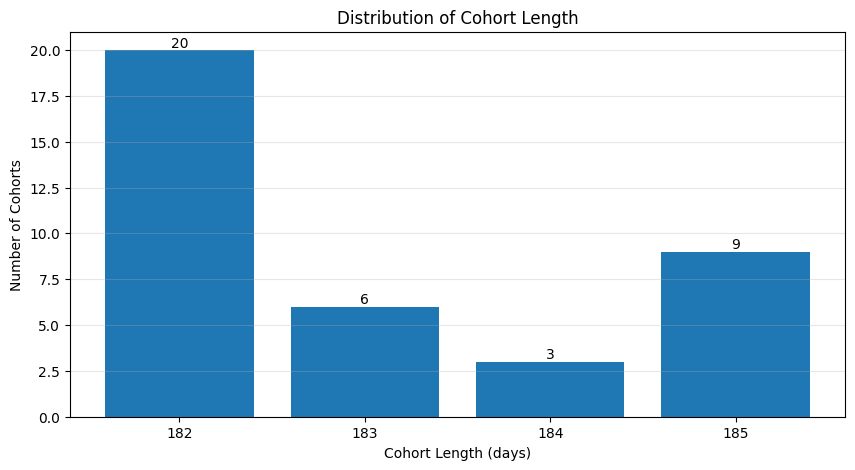

In [21]:
dist = (
    cohort_length['cohort_length']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    dist.index.astype(str),
    dist.values
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xlabel('Cohort Length (days)')
plt.ylabel('Number of Cohorts')
plt.title('Distribution of Cohort Length')
plt.grid(axis='y', alpha=0.3)

plt.show()

Distribution of running revenue per cohort

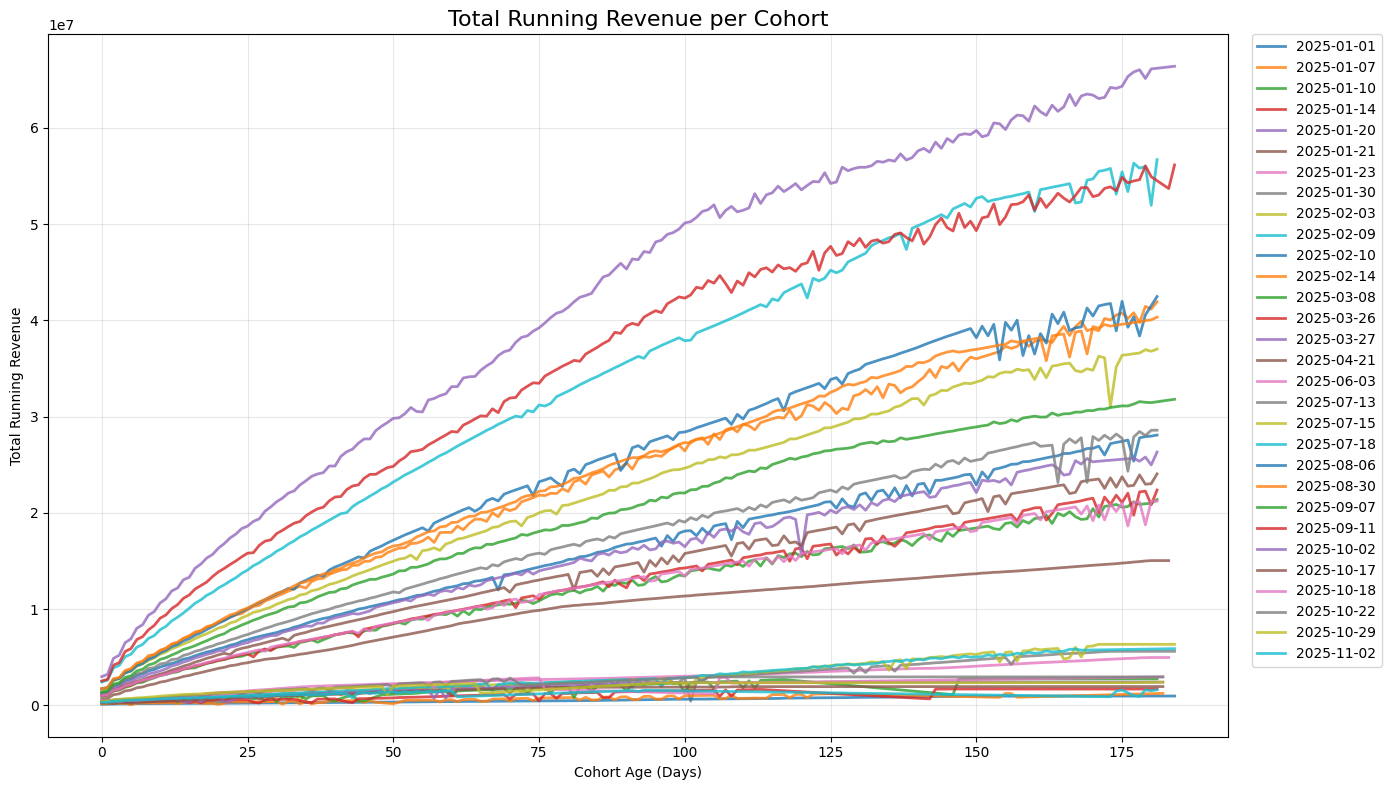

In [22]:
import matplotlib.pyplot as plt

sample = (
    df["date_created_at"]
    .drop_duplicates()
    .sample(min(30, df["date_created_at"].nunique()), random_state=42)
)

plt.figure(figsize=(14, 8))

for cohort in sorted(sample):

    temp = (
        df[df["date_created_at"] == cohort]
        .groupby("cohort_age", as_index=False)["revenue_running_total"]
        .sum()
        .sort_values("cohort_age")
    )

    plt.plot(
        temp["cohort_age"],
        temp["revenue_running_total"],
        linewidth=2,
        alpha=0.8,
        label=cohort.strftime("%Y-%m-%d")
    )

plt.title("Total Running Revenue per Cohort", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Total Running Revenue")
plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

Average revenue daily push distribution per-cohort age per-adnet

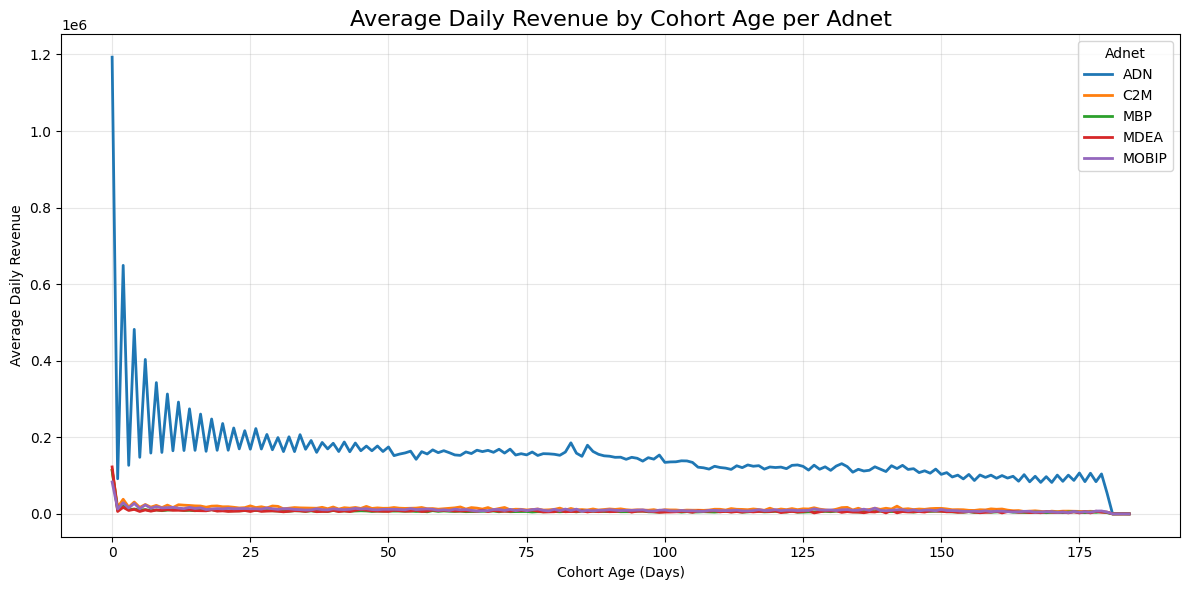

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for adnet, temp in (
    df.groupby("adnet")
):

    avg_daily = (
        temp
        .groupby("cohort_age")["revenue_dailypush"]
        .mean()
    )

    plt.plot(
        avg_daily.index,
        avg_daily.values,
        linewidth=2,
        label=adnet
    )

plt.title("Average Daily Revenue by Cohort Age per Adnet", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Average Daily Revenue")
plt.grid(alpha=0.3)
plt.legend(title="Adnet")

plt.tight_layout()
plt.show()

Average total revenue distribution per cohort age

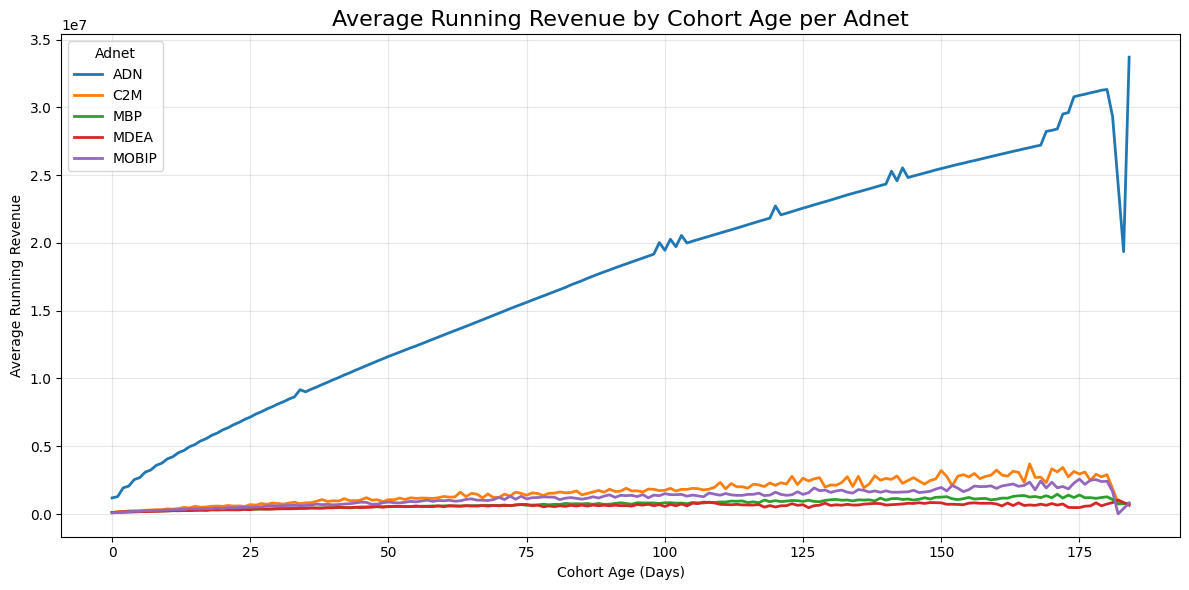

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

for adnet, temp in df.groupby("adnet"):

    avg_running = (
        temp
        .groupby("cohort_age")["revenue_running_total"]
        .mean()
    )

    plt.plot(
        avg_running.index,
        avg_running.values,
        linewidth=2,
        label=adnet
    )

plt.title("Average Running Revenue by Cohort Age per Adnet", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Average Running Revenue")
plt.grid(alpha=0.3)
plt.legend(title="Adnet")

plt.tight_layout()
plt.show()

Numerical correlation

<Axes: >

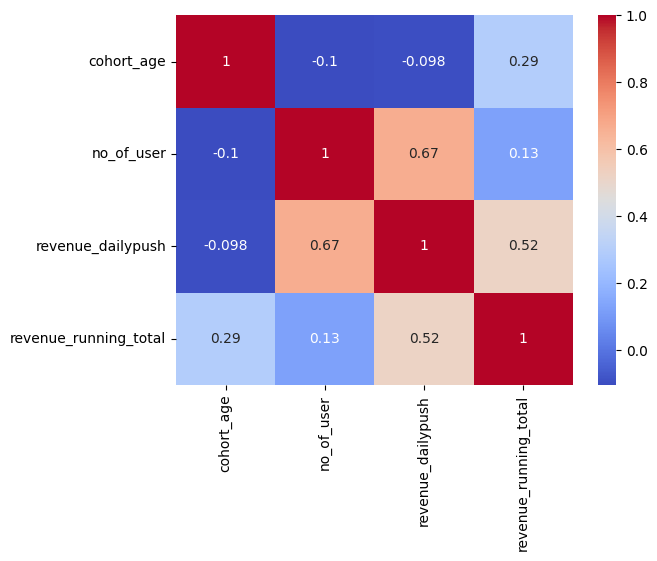

In [25]:
numeric_cols = [
    'cohort_age',
    'no_of_user',
    'revenue_dailypush',
    'revenue_running_total'
]

corr = df[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

## Preprocessing

### Sort Data

Final preparation with sorting date created and cohort age

In [26]:
df = (
    df
    .sort_values(
        ['date_created_at', 'cohort_age']
    )
    .reset_index(drop=True)
)

In [27]:
df.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-01-01,C2M,2025-01-01,86,6000.0,FIRSTPUSH,6000.0,0
1,2025-01-01,MBP,2025-01-01,686,136000.0,FIRSTPUSH,136000.0,0
2,2025-01-01,ADN,2025-01-01,2662,1054000.0,FIRSTPUSH,1054000.0,0
3,2025-01-01,MOBIP,2025-01-01,596,68000.0,FIRSTPUSH,68000.0,0
4,2025-01-01,MOBIP,2025-01-02,8,16000.0,DAILYPUSH,84000.0,1


### Feature Selection

Selecting feature for new dataframe

In [28]:
KEEP_COLS = [
    'date_created_at',
    'adnet',
    'cohort_age',
    'revenue_running_total',
]

df_model = df[KEEP_COLS].copy()

In [29]:
df_model.head()

,date_created_at,adnet,cohort_age,revenue_running_total
0,2025-01-01,C2M,0,6000.0
1,2025-01-01,MBP,0,136000.0
2,2025-01-01,ADN,0,1054000.0
3,2025-01-01,MOBIP,0,68000.0
4,2025-01-01,MOBIP,1,84000.0


### Continuity Check & Gap Filling

TimesFM ignores `cohort_age` itself — it assumes every element of the input array is one evenly-spaced step (1 day). If `cohort_age` skips days, the model treats the next value as if it immediately follows the previous one, which distorts the timeline and the seed/horizon counts.

`revenue_running_total` is a **cumulative** metric, so a missing day's value equals the last known total. We therefore reindex each (cohort, adnet) series onto a gap-free daily grid (`cohort_age` 0..max) and **forward-fill** the running total; any leading gap before the first record is set to 0.

In [30]:
# def count_gaps(data, group_cols=("date_created_at", "adnet"), age_col="cohort_age"):
#     """List (cohort, adnet) series whose cohort_age is not a continuous range."""
#     rows = []
#     for keys, g in data.groupby(list(group_cols)):
#         span = int(g[age_col].max() - g[age_col].min() + 1)
#         missing = span - g[age_col].nunique()
#         if missing > 0:
#             keys = keys if isinstance(keys, tuple) else (keys,)
#             rows.append((*keys, missing))
#     return rows

# gaps = count_gaps(df_model)
# print("Series with gaps:", len(gaps))
# for r in gaps[:20]:
#     print(r)

In [31]:
# def make_continuous(data, target="revenue_running_total",
#                     group_cols=("date_created_at", "adnet"),
#                     age_col="cohort_age"):
#     """
#     Reindex each (cohort, adnet) series onto a gap-free daily grid
#     (cohort_age 0..max) so TimesFM sees an evenly-spaced series.

#     revenue_running_total is cumulative, so missing days are
#     forward-filled; any leading gap before the first record is 0.
#     """
#     group_cols = list(group_cols)
#     out = []

#     for keys, g in data.groupby(group_cols):
#         g = g.sort_values(age_col)
#         full = range(0, int(g[age_col].max()) + 1)

#         g = g.set_index(age_col).reindex(full)

#         keys = keys if isinstance(keys, tuple) else (keys,)
#         for col, val in zip(group_cols, keys):
#             g[col] = val

#         g[target] = g[target].ffill().fillna(0.0)
#         out.append(g.reset_index())

#     return pd.concat(out, ignore_index=True)

# df_model = make_continuous(df_model)

# print("Gaps remaining after fill:", len(count_gaps(df_model)))
# df_model.head()

### Split Data

Split to train 90% and validation 10% from total cohorts

In [32]:
cohorts = sorted(df_model['date_created_at'].unique())

split_idx = int(len(cohorts) * 0.9)

train_cohorts = cohorts[:split_idx]
val_cohorts = cohorts[split_idx:]

In [33]:
print("Total Train Cohort:", len(train_cohorts))
print("Sample Train Cohort:", train_cohorts)

print("Total Val Cohort:", len(val_cohorts))
print("Sample Val Cohort:", val_cohorts)

Total Train Cohort: 34
Sample Train Cohort: [datetime.date(2025, 1, 1), datetime.date(2025, 1, 7), datetime.date(2025, 1, 10), datetime.date(2025, 1, 14), datetime.date(2025, 1, 20), datetime.date(2025, 1, 21), datetime.date(2025, 1, 23), datetime.date(2025, 1, 28), datetime.date(2025, 1, 30), datetime.date(2025, 2, 3), datetime.date(2025, 2, 8), datetime.date(2025, 2, 9), datetime.date(2025, 2, 10), datetime.date(2025, 2, 14), datetime.date(2025, 2, 17), datetime.date(2025, 3, 8), datetime.date(2025, 3, 26), datetime.date(2025, 3, 27), datetime.date(2025, 3, 30), datetime.date(2025, 4, 21), datetime.date(2025, 5, 13), datetime.date(2025, 6, 3), datetime.date(2025, 6, 24), datetime.date(2025, 7, 13), datetime.date(2025, 7, 15), datetime.date(2025, 7, 18), datetime.date(2025, 8, 6), datetime.date(2025, 8, 30), datetime.date(2025, 9, 2), datetime.date(2025, 9, 7), datetime.date(2025, 9, 11), datetime.date(2025, 9, 17), datetime.date(2025, 10, 2), datetime.date(2025, 10, 17)]
Total Val Co

Insert to pandas for next step (forecasting)

In [34]:
train_df = df_model[df_model['date_created_at'].isin(train_cohorts)]
val_df = df_model[df_model['date_created_at'].isin(val_cohorts)]

In [35]:
print("Total Cohorts Train:", train_df["date_created_at"].nunique())
print("")
print("Total Adnets:", train_df["adnet"].nunique())
print(train_df["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", train_df.groupby("adnet")["date_created_at"].nunique())

Total Cohorts Train: 34

Total Adnets: 5
['C2M' 'MBP' 'ADN' 'MOBIP' 'MDEA']

Total Cohorts per Adnet: adnet
ADN      26
C2M      20
MBP      29
MDEA     12
MOBIP    20
Name: date_created_at, dtype: int64


In [36]:
print("Total Cohorts Val:", val_df["date_created_at"].nunique())
print("")
print("Total Adnets:", val_df["adnet"].nunique())
print(val_df["adnet"].unique())
print("")
print("Total Cohorts per Adnet:", val_df.groupby("adnet")["date_created_at"].nunique())

Total Cohorts Val: 4

Total Adnets: 4
['MDEA' 'MOBIP' 'C2M' 'MBP']

Total Cohorts per Adnet: adnet
C2M      4
MBP      4
MDEA     4
MOBIP    2
Name: date_created_at, dtype: int64


### Target

Setup feature and target for training

In [37]:
TARGET = 'revenue_running_total'

TimesFM is a univariate, zero-shot foundation model that normalizes its inputs internally, so no manual scaling is applied. It consumes only the ordered `revenue_running_total` series; `cohort_age` is kept solely to order each series and slice seed/horizon, and `adnet` to separate series.

Checking data train

In [38]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14777 entries, 0 to 14776
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        14777 non-null  dbdate 
 1   adnet                  14777 non-null  object 
 2   cohort_age             14777 non-null  int64  
 3   revenue_running_total  14777 non-null  float64
dtypes: dbdate(1), float64(1), int64(1), object(1)
memory usage: 577.2+ KB


In [39]:
train_df.head()

,date_created_at,adnet,cohort_age,revenue_running_total
0,2025-01-01,C2M,0,6000.0
1,2025-01-01,MBP,0,136000.0
2,2025-01-01,ADN,0,1054000.0
3,2025-01-01,MOBIP,0,68000.0
4,2025-01-01,MOBIP,1,84000.0


Checking data validation

In [40]:
val_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 791 entries, 14777 to 15567
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date_created_at        791 non-null    dbdate 
 1   adnet                  791 non-null    object 
 2   cohort_age             791 non-null    int64  
 3   revenue_running_total  791 non-null    float64
dtypes: dbdate(1), float64(1), int64(1), object(1)
memory usage: 30.9+ KB


In [41]:
val_df.head()

,date_created_at,adnet,cohort_age,revenue_running_total
14777,2025-10-18,MDEA,0,222000.0
14778,2025-10-18,MOBIP,0,4000.0
14779,2025-10-18,C2M,0,118000.0
14780,2025-10-18,MBP,0,126000.0
14781,2025-10-18,MBP,1,128000.0


## Forecast Setup

### Series Builder

TimesFM forecasts a whole horizon from a contiguous context window, so instead of sliding windows we simply extract the ordered target series for each cohort. TimesFM 2.5 no longer requires a frequency indicator — the model handles the temporal pattern automatically.

In [42]:
CONTEXT_LEN = 2048   # max context length (2.5 supports up to 16k)
HORIZON_LEN = 512    # max forecast horizon per call
CONTEXT_MIN = 30     # minimum history required before forecasting
# Note: TimesFM 2.5 removed the frequency indicator — no FREQ needed

def get_series(data, cohort, adnet):
    """
    Return the ordered univariate target series for one
    (date_created_at, adnet).
    """

    s = (
        data[
            (data["date_created_at"] == cohort) &
            (data["adnet"] == adnet)
        ]
        .sort_values("cohort_age")
    )

    return s[TARGET].to_numpy(dtype=float)

## Modeling

### TimesFM

TimesFM is a pretrained foundation model, so it is used zero-shot — there is no training loop. Load the 2.5 200M PyTorch checkpoint with the fixed architecture parameters.

In [43]:
import torch
import timesfm

torch.set_float32_matmul_precision("high")

# TimesFM 2.5 – 200M parameter checkpoint (PyTorch)
tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained(
    "google/timesfm-2.5-200m-pytorch"
)

tfm.compile(
    timesfm.ForecastConfig(
        max_context=CONTEXT_LEN,
        max_horizon=HORIZON_LEN,
        normalize_inputs=True,
        use_continuous_quantile_head=False,   # point forecast only
        force_flip_invariance=False,
        infer_is_positive=True,               # revenue is always >= 0
        fix_quantile_crossing=True,
    )
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


## Evaluation

### Visualization

Evaluate zero-shot on the validation cohorts: for each cohort use all but the last `EVAL_HORIZON` days as context and forecast the held-out tail, then compare against the actuals.

In [44]:
EVAL_HORIZON = 30

eval_contexts = []
eval_actuals = []

evaluated_series = []

for cohort in val_cohorts:

    adnets = (
        val_df.loc[
            val_df["date_created_at"] == cohort,
            "adnet"
        ]
        .unique()
    )

    for adnet in adnets:

        s = get_series(val_df, cohort, adnet)

        if len(s) < CONTEXT_MIN + EVAL_HORIZON:
            continue

        eval_contexts.append(s[:-EVAL_HORIZON])
        eval_actuals.append(s[-EVAL_HORIZON:])

        evaluated_series.append((cohort, adnet))

print("Evaluated series:", len(eval_contexts))

point_forecast, _ = tfm.forecast(
    horizon=EVAL_HORIZON,
    inputs=eval_contexts,
)

y_pred = np.concatenate([
    point_forecast[i, :EVAL_HORIZON]
    for i in range(len(eval_contexts))
])

y_val = np.concatenate(eval_actuals)

Evaluated series: 10


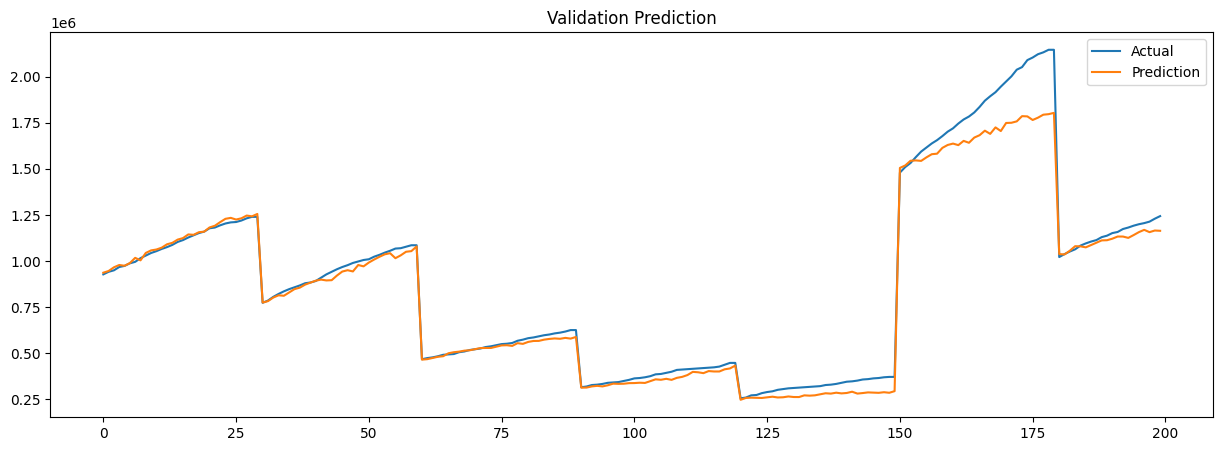

In [45]:
plt.figure(figsize=(15,5))

plt.plot(
    y_val[:200],
    label='Actual'
)

plt.plot(
    y_pred[:200],
    label='Prediction'
)

plt.title('Validation Prediction')

plt.legend()

plt.show()

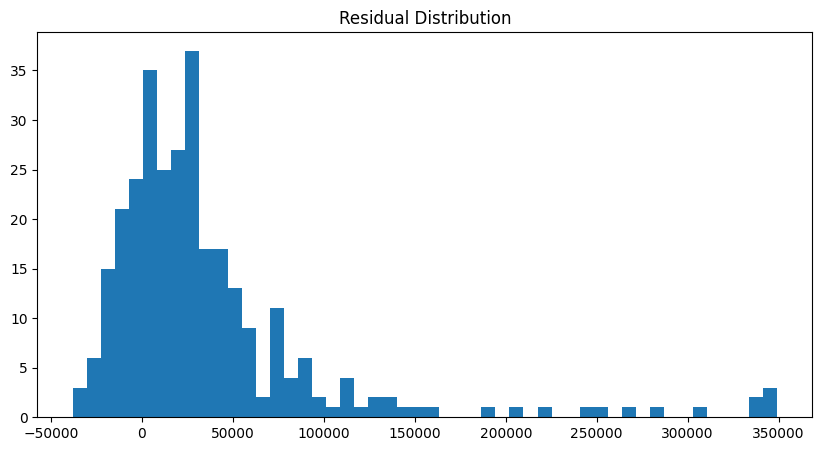

In [46]:
residuals = y_val - y_pred

plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=50
)

plt.title('Residual Distribution')

plt.show()

### Metrics

Detail evaluation metrics in MAE, RMSE, MAPE

In [47]:
mae = mean_absolute_error(
    y_val,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred
    )
)

mape = mean_absolute_percentage_error(
    y_val,
    y_pred
) * 100

In [48]:
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 42215.564063
RMSE : 73676.961271
MAPE : 5.15%


## Projection

Use the first `SEED_DAYS` of a cohort as context and let TimesFM forecast all remaining days in a single multi-horizon call (no recursive stepping needed).

Select cohort and run projection

In [49]:
candidates = [
    c for c in val_cohorts
    if int(
        df[df["date_created_at"] == c]["cohort_age"].max()
    ) >= SEED_DAYS
]

print("Eligible cohorts:", len(candidates))

# Pilih cohort
cohort = candidates[1]

# Lihat adnet yang tersedia pada cohort tersebut
available_adnets = (
    df.loc[
        df["date_created_at"] == cohort,
        "adnet"
    ]
    .unique()
)

print("Available Adnets:", available_adnets)

adnet = available_adnets[0]
# adnet = "MBP"
# adnet = "ADN"
# adnet = "MOBIP"
# adnet = "MDEA"

cohort_raw = (
    df[
        (df["date_created_at"] == cohort) &
        (df["adnet"] == adnet)
    ]
    .sort_values("cohort_age")
    .reset_index(drop=True)
)

seed_mask = cohort_raw["cohort_age"] < SEED_DAYS

context = cohort_raw.loc[
    seed_mask,
    TARGET
].values.astype(float)

actual_future = cohort_raw.loc[
    ~seed_mask,
    TARGET
].values.astype(float)

n_steps = len(actual_future)

print("Cohort      :", cohort)
print("Adnet       :", adnet)
print("Seed days   :", len(context))
print("Future days :", n_steps)

# Forecast
point_forecast, _ = tfm.forecast(
    horizon=n_steps,
    inputs=[context],
)

pred_future = point_forecast[0, :n_steps]

print(
    f"Predicted running total at day "
    f"{SEED_DAYS + n_steps - 1}: "
    f"{pred_future[-1]:,.0f}"
)

print(
    f"Actual    running total at day "
    f"{SEED_DAYS + n_steps - 1}: "
    f"{actual_future[-1]:,.0f}"
)

Eligible cohorts: 4
Available Adnets: ['MDEA' 'MBP' 'C2M' 'MOBIP']
Cohort      : 2025-10-22
Adnet       : MDEA
Seed days   : 52
Future days : 15
Predicted running total at day 74: 434,688
Actual    running total at day 74: 448,000


Actual vs projection visualization

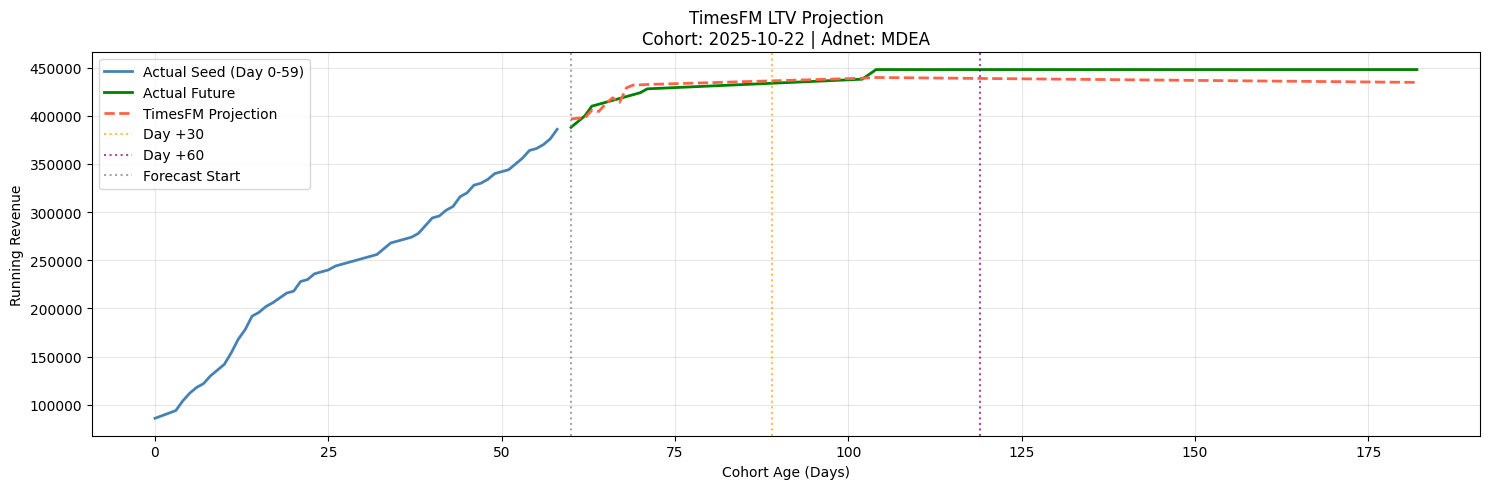

In [50]:
seed_age = cohort_raw.loc[
    seed_mask,
    "cohort_age"
].values

future_age = cohort_raw.loc[
    ~seed_mask,
    "cohort_age"
].values[:n_steps]

pred_age = future_age[:len(pred_future)]

plt.figure(figsize=(15, 5))

plt.plot(
    seed_age,
    context,
    label=f"Actual Seed (Day 0-{SEED_DAYS-1})",
    color="steelblue",
    linewidth=2
)

plt.plot(
    future_age,
    actual_future,
    label="Actual Future",
    color="green",
    linewidth=2
)

plt.plot(
    pred_age,
    pred_future,
    label="TimesFM Projection",
    color="tomato",
    linestyle="--",
    linewidth=2
)

for offset, color in [(30, "orange"), (60, "purple")]:
    day = SEED_DAYS + offset - 1
    if len(future_age) > 0 and day <= future_age[-1]:
        plt.axvline(
            x=day,
            color=color,
            linestyle=":",
            alpha=0.7,
            label=f"Day +{offset}"
        )

plt.axvline(
    x=SEED_DAYS,
    color="gray",
    linestyle=":",
    alpha=0.7,
    label="Forecast Start"
)

plt.title(
    f"TimesFM LTV Projection\n"
    f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}"
)

plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Testing on Unseen Data

This section evaluates TimesFM on a completely hold-out dataset (`linkit-rnd-475909.country_summary.ml_lstm_unseen_5cohorts`) containing 5 unseen cohorts that the model has never been exposed to.

Because TimesFM is a **univariate, zero-shot** foundation model, the unseen data needs only minimal preparation: load the raw table, derive `cohort_age` (used to order the series and slice seed/horizon), and sort. No scaler or encoder is fit, no scaling is applied, and `day_of_week` / encodings are not needed — the model consumes the raw `revenue_running_total` series directly.

### Loader

Query the unseen testing table from Google BigQuery

In [51]:
# df_unseen = pd.read_gbq(unseen_query, project_id=project_id, dialect='standard')
# df_unseen.head()

df_unseen = unseen_raw.copy()

### Feature Engineering

Derive `cohort_age` and sort the same way as the training data. Scaling, encoding, and `day_of_week` are intentionally skipped since TimesFM only uses the ordered target series.

In [52]:
df_unseen['date_created_at'] = pd.to_datetime(df_unseen['date_created_at'])
df_unseen['date_update']     = pd.to_datetime(df_unseen['date_update'])

df_unseen['cohort_age'] = (
    df_unseen['date_update'] - df_unseen['date_created_at']
).dt.days

df_unseen = (
    df_unseen
    .sort_values(['date_created_at', 'cohort_age'])
    .reset_index(drop=True)
)

df_unseen.head()

,date_created_at,adnet,date_update,no_of_user,revenue_dailypush,subject,revenue_running_total,cohort_age
0,2025-11-05,MBP,2025-11-05,975,156000.0,FIRSTPUSH,156000.0,0
1,2025-11-05,MDEA,2025-11-05,955,142000.0,FIRSTPUSH,142000.0,0
2,2025-11-05,MDEA,2025-11-06,6,12000.0,DAILYPUSH,154000.0,1
3,2025-11-05,MBP,2025-11-06,5,10000.0,DAILYPUSH,166000.0,1
4,2025-11-05,MDEA,2025-11-07,15,30000.0,DAILYPUSH,184000.0,2


Apply the same gap-filling so the unseen series are also evenly spaced.

In [53]:
# # df_unseen = make_continuous(df_unseen)

# print("Unseen gaps remaining after fill:", len(count_gaps(df_unseen)))
# df_unseen.head()

Checking unseen cohorts and their length

In [54]:
unseen_cohorts = sorted(df_unseen["date_created_at"].unique())

print("Total unseen cohorts:", len(unseen_cohorts))

for cohort in unseen_cohorts:

    print(f"\nCohort: {str(cohort)[:10]}")

    temp = (
        df_unseen[
            df_unseen["date_created_at"] == cohort
        ]
        .groupby("adnet")["cohort_age"]
        .max()
        .sort_index()
    )

    for adnet, max_age in temp.items():
        print(f"  {adnet:<6} -> {int(max_age)+1} days")

Total unseen cohorts: 4

Cohort: 2025-11-05
  MBP    -> 182 days
  MDEA   -> 182 days

Cohort: 2025-11-20
  MBP    -> 182 days
  MDEA   -> 182 days

Cohort: 2025-11-29
  MBP    -> 182 days
  MDEA   -> 182 days

Cohort: 2025-12-05
  MBP    -> 183 days
  MDEA   -> 183 days


### Visualization

Distribution of running revenue per cohort

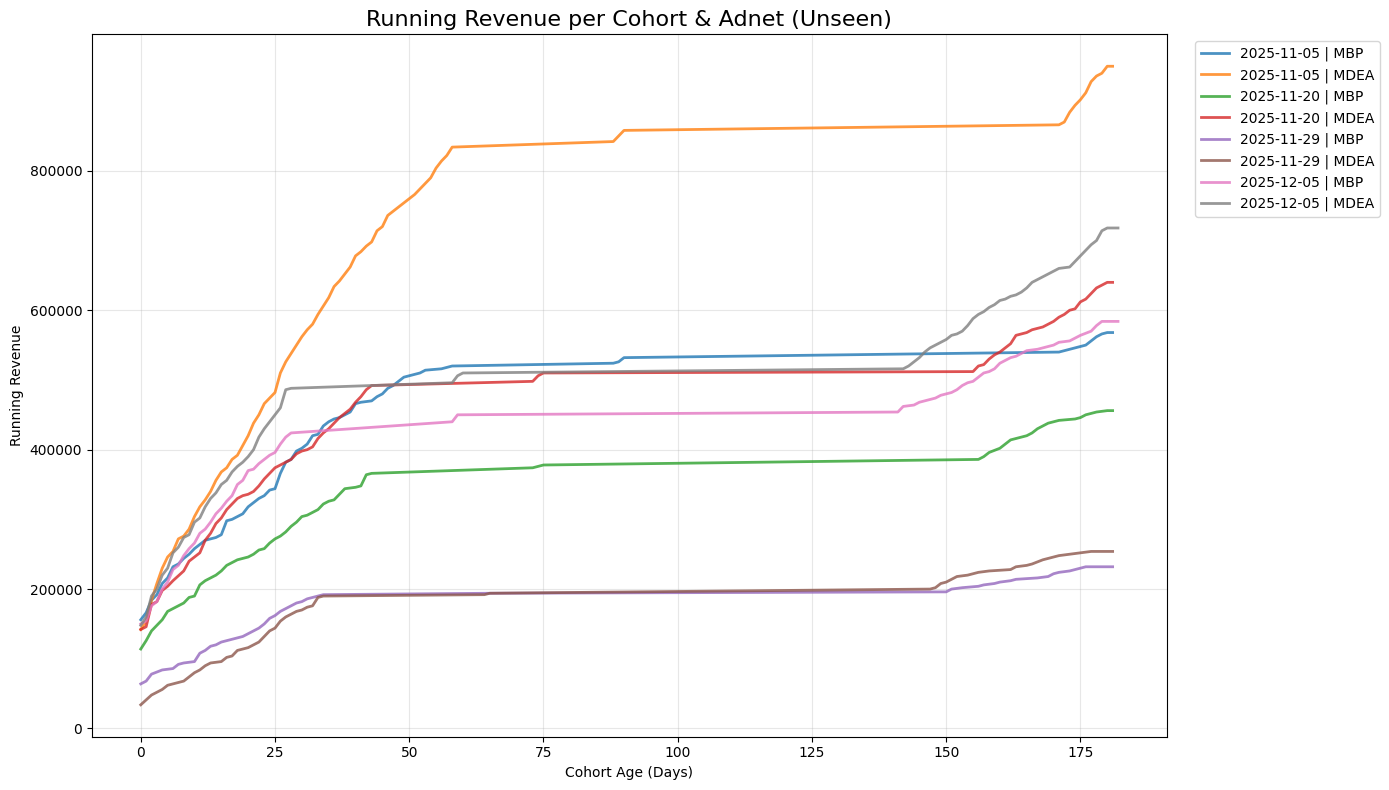

In [55]:
plt.figure(figsize=(14, 8))

for (cohort, adnet), temp in (
    df_unseen
    .groupby(["date_created_at", "adnet"])
):

    temp = temp.sort_values("cohort_age")

    plt.plot(
        temp["cohort_age"],
        temp["revenue_running_total"],
        linewidth=2,
        alpha=0.8,
        label=f"{pd.Timestamp(cohort).strftime('%Y-%m-%d')} | {adnet}"
    )

plt.title("Running Revenue per Cohort & Adnet (Unseen)", fontsize=16)
plt.xlabel("Cohort Age (Days)")
plt.ylabel("Running Revenue")

plt.grid(alpha=0.3)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [56]:
def project_cohort(cohort_raw, seed_len):
    """
    Project LTV for one (cohort, adnet) time series using TimesFM.

    Args:
        cohort_raw: DataFrame for one (date_created_at, adnet), sorted by cohort_age
        seed_len: Number of days used as context

    Returns:
        context, actual_future, pred_future, n_steps
    """

    seed_mask = cohort_raw["cohort_age"] < seed_len

    context = (
        cohort_raw.loc[
            seed_mask,
            TARGET
        ]
        .values
        .astype(float)
    )

    actual_future = (
        cohort_raw.loc[
            ~seed_mask,
            TARGET
        ]
        .values
        .astype(float)
    )

    n_steps = len(actual_future)

    point_forecast, _ = tfm.forecast(
        horizon=n_steps,
        inputs=[context],
    )

    pred_future = point_forecast[0, :n_steps]

    return context, actual_future, pred_future, n_steps

## Forecast - 30 Cohorts - 1 Adnet - 7 Days

For each unseen cohort, use the first `SEED_DAYS` days as context and let TimesFM forecast the remaining horizon in a single call. If a cohort is shorter than `SEED_DAYS`, the seed length is reduced so at least one day is forecast.

In [ ]:
results = {}

for (cohort, adnet), cohort_raw in (
    df_unseen
    .groupby(["date_created_at", "adnet"])
):

    cohort_raw = (
        cohort_raw
        .sort_values("cohort_age")
        .reset_index(drop=True)
    )

    if len(cohort_raw) < 2:
        continue

    seed_len = min(SEED_DAYS, len(cohort_raw) - 1)

    context, actual_future, pred_future, n_steps = project_cohort(
        cohort_raw,
        seed_len
    )

    results[(cohort, adnet)] = {
        "cohort_raw": cohort_raw,
        "adnet": adnet,
        "seed_len": seed_len,
        "context": context,
        "actual_future": actual_future,
        "pred_future": pred_future,
        "n_steps": n_steps,
    }

    mape_full = (
        mean_absolute_percentage_error(
            actual_future,
            pred_future
        ) * 100
    )

    print(
        f"{str(cohort)[:10]} | {adnet:<6} "
        f"seed={seed_len:>2}d "
        f"forecast={n_steps:>3}d "
        f"| final pred={pred_future[-1]:>12,.0f} "
        f"actual={actual_future[-1]:>12,.0f} "
        f"MAPE={mape_full:.2f}%"
    )

2025-08-02 | MBP    seed= 7d forecast=142d | final pred=     238,553 actual=   1,344,000 MAPE=63.04%
2025-08-06 | MBP    seed= 7d forecast=130d | final pred=     155,763 actual=     980,000 MAPE=62.15%
2025-08-10 | MBP    seed= 7d forecast=139d | final pred=     239,727 actual=   1,306,000 MAPE=61.12%


Actual vs projection visualization for each unseen cohort

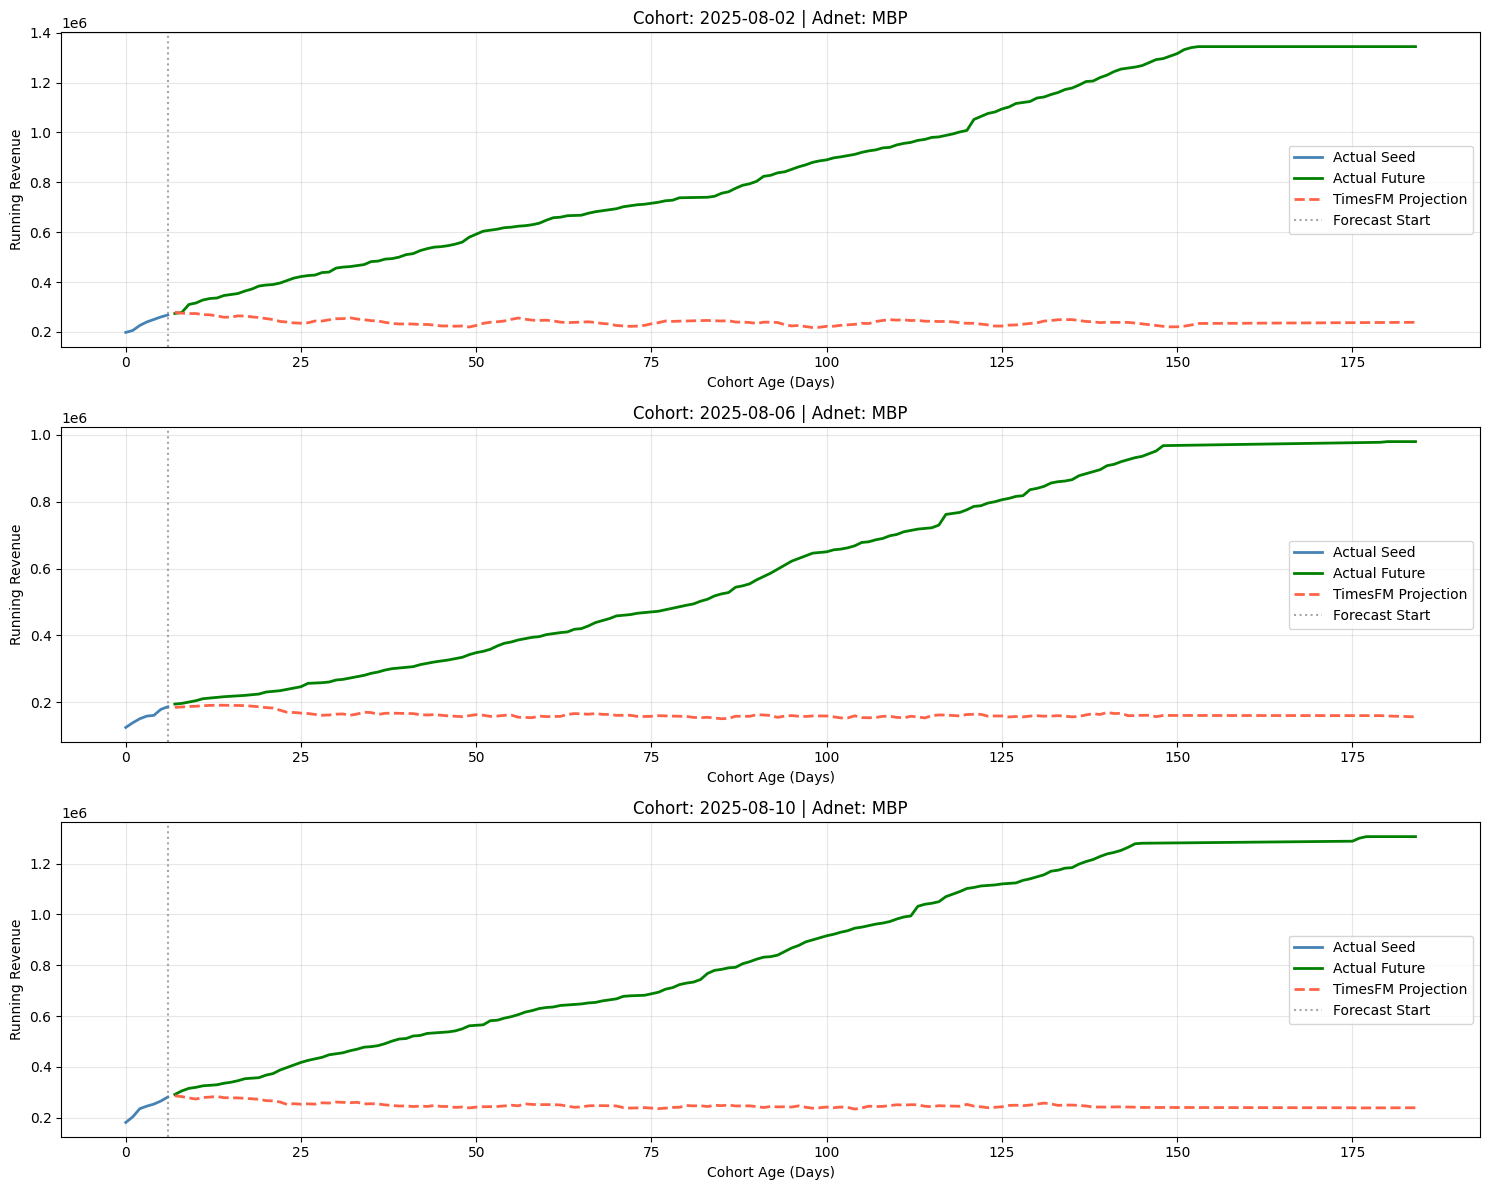

In [ ]:
n_series = len(results)

fig, axes = plt.subplots(
    n_series,
    1,
    figsize=(15, 4 * n_series)
)

if n_series == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results.items()):

    cohort_raw = r["cohort_raw"]
    seed_len = r["seed_len"]
    n_steps = r["n_steps"]

    seed_mask = cohort_raw["cohort_age"] < seed_len

    ages = cohort_raw["cohort_age"].values

    seed_age = ages[seed_mask]
    future_age = ages[~seed_mask][:n_steps]
    pred_age = future_age[:len(r["pred_future"])]

    ax.plot(
        seed_age,
        r["context"],
        label="Actual Seed",
        color="steelblue",
        linewidth=2
    )

    ax.plot(
        future_age,
        r["actual_future"],
        label="Actual Future",
        color="green",
        linewidth=2
    )

    ax.plot(
        pred_age,
        r["pred_future"],
        label="TimesFM Projection",
        color="tomato",
        linestyle="--",
        linewidth=2
    )

    if len(seed_age) > 0:
        ax.axvline(
            x=seed_age[-1],
            color="gray",
            linestyle=":",
            alpha=0.7,
            label="Forecast Start"
        )

    ax.set_title(
        f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}"
    )

    ax.set_xlabel("Cohort Age (Days)")
    ax.set_ylabel("Running Revenue")

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()



## Forecast - 30 Cohorts - 1 Adnet - 30 Days

In [74]:
results = {}

for (cohort, adnet), cohort_raw in (
    df_unseen
    .groupby(["date_created_at", "adnet"])
):

    cohort_raw = (
        cohort_raw
        .sort_values("cohort_age")
        .reset_index(drop=True)
    )

    if len(cohort_raw) < 2:
        continue

    seed_len = min(SEED_DAYS, len(cohort_raw) - 1)

    context, actual_future, pred_future, n_steps = project_cohort(
        cohort_raw,
        seed_len
    )

    results[(cohort, adnet)] = {
        "cohort_raw": cohort_raw,
        "adnet": adnet,
        "seed_len": seed_len,
        "context": context,
        "actual_future": actual_future,
        "pred_future": pred_future,
        "n_steps": n_steps,
    }

    mape_full = (
        mean_absolute_percentage_error(
            actual_future,
            pred_future
        ) * 100
    )

    print(
        f"{str(cohort)[:10]} | {adnet:<6} "
        f"seed={seed_len:>2}d "
        f"forecast={n_steps:>3}d "
        f"| final pred={pred_future[-1]:>12,.0f} "
        f"actual={actual_future[-1]:>12,.0f} "
        f"MAPE={mape_full:.2f}%"
    )

2025-08-02 | MBP    seed=30d forecast=119d | final pred=     423,558 actual=   1,344,000 MAPE=36.29%
2025-08-06 | MBP    seed=30d forecast=111d | final pred=     243,781 actual=     980,000 MAPE=45.68%
2025-08-10 | MBP    seed=30d forecast=117d | final pred=     390,601 actual=   1,306,000 MAPE=41.00%


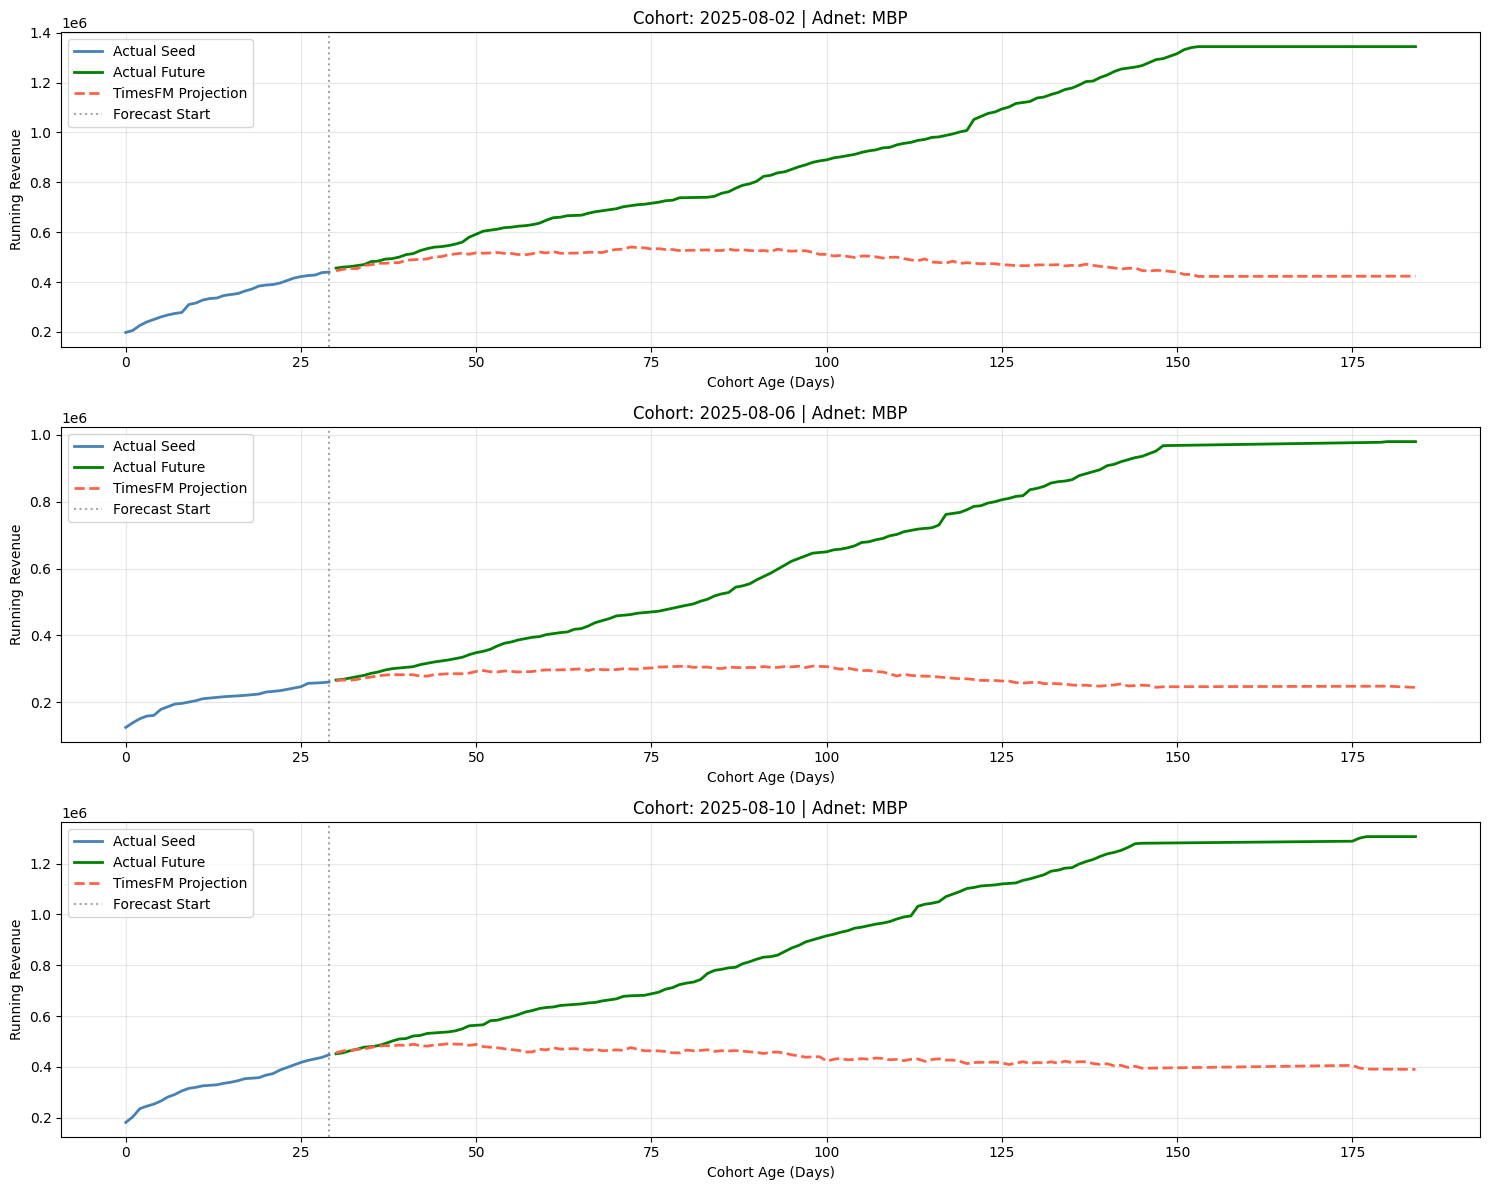

In [75]:
n_series = len(results)

fig, axes = plt.subplots(
    n_series,
    1,
    figsize=(15, 4 * n_series)
)

if n_series == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results.items()):

    cohort_raw = r["cohort_raw"]
    seed_len = r["seed_len"]
    n_steps = r["n_steps"]

    seed_mask = cohort_raw["cohort_age"] < seed_len

    ages = cohort_raw["cohort_age"].values

    seed_age = ages[seed_mask]
    future_age = ages[~seed_mask][:n_steps]
    pred_age = future_age[:len(r["pred_future"])]

    ax.plot(
        seed_age,
        r["context"],
        label="Actual Seed",
        color="steelblue",
        linewidth=2
    )

    ax.plot(
        future_age,
        r["actual_future"],
        label="Actual Future",
        color="green",
        linewidth=2
    )

    ax.plot(
        pred_age,
        r["pred_future"],
        label="TimesFM Projection",
        color="tomato",
        linestyle="--",
        linewidth=2
    )

    if len(seed_age) > 0:
        ax.axvline(
            x=seed_age[-1],
            color="gray",
            linestyle=":",
            alpha=0.7,
            label="Forecast Start"
        )

    ax.set_title(
        f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}"
    )

    ax.set_xlabel("Cohort Age (Days)")
    ax.set_ylabel("Running Revenue")

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()



## Forecast - 30 Cohorts - 1 Adnet - 60 Days

In [57]:
results = {}

for (cohort, adnet), cohort_raw in (
    df_unseen
    .groupby(["date_created_at", "adnet"])
):

    cohort_raw = (
        cohort_raw
        .sort_values("cohort_age")
        .reset_index(drop=True)
    )

    if len(cohort_raw) < 2:
        continue

    seed_len = min(SEED_DAYS, len(cohort_raw) - 1)

    context, actual_future, pred_future, n_steps = project_cohort(
        cohort_raw,
        seed_len
    )

    results[(cohort, adnet)] = {
        "cohort_raw": cohort_raw,
        "adnet": adnet,
        "seed_len": seed_len,
        "context": context,
        "actual_future": actual_future,
        "pred_future": pred_future,
        "n_steps": n_steps,
    }

    mape_full = (
        mean_absolute_percentage_error(
            actual_future,
            pred_future
        ) * 100
    )

    print(
        f"{str(cohort)[:10]} | {adnet:<6} "
        f"seed={seed_len:>2}d "
        f"forecast={n_steps:>3}d "
        f"| final pred={pred_future[-1]:>12,.0f} "
        f"actual={actual_future[-1]:>12,.0f} "
        f"MAPE={mape_full:.2f}%"
    )

2025-08-02 | MBP    seed=60d forecast= 89d | final pred=     864,385 actual=   1,344,000 MAPE=18.93%
2025-08-06 | MBP    seed=60d forecast= 86d | final pred=     696,736 actual=     980,000 MAPE=15.19%
2025-08-10 | MBP    seed=60d forecast= 87d | final pred=     987,346 actual=   1,306,000 MAPE=14.58%


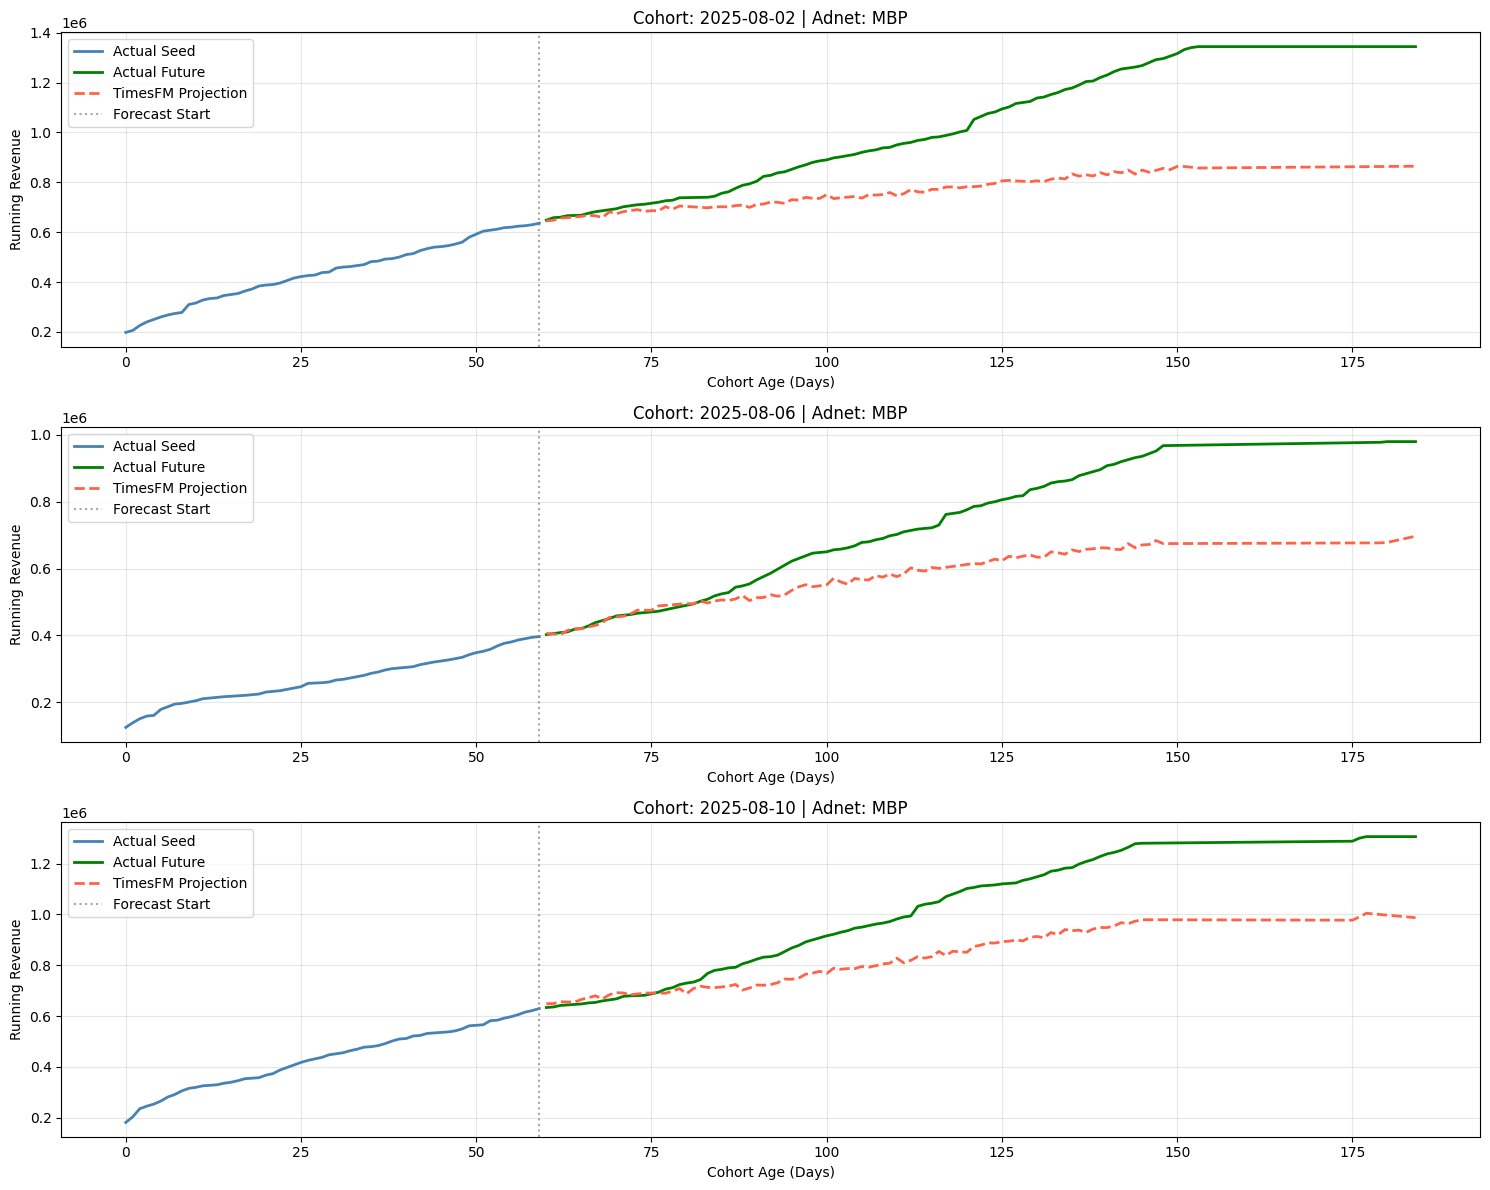

In [58]:
n_series = len(results)

fig, axes = plt.subplots(
    n_series,
    1,
    figsize=(15, 4 * n_series)
)

if n_series == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results.items()):

    cohort_raw = r["cohort_raw"]
    seed_len = r["seed_len"]
    n_steps = r["n_steps"]

    seed_mask = cohort_raw["cohort_age"] < seed_len

    ages = cohort_raw["cohort_age"].values

    seed_age = ages[seed_mask]
    future_age = ages[~seed_mask][:n_steps]
    pred_age = future_age[:len(r["pred_future"])]

    ax.plot(
        seed_age,
        r["context"],
        label="Actual Seed",
        color="steelblue",
        linewidth=2
    )

    ax.plot(
        future_age,
        r["actual_future"],
        label="Actual Future",
        color="green",
        linewidth=2
    )

    ax.plot(
        pred_age,
        r["pred_future"],
        label="TimesFM Projection",
        color="tomato",
        linestyle="--",
        linewidth=2
    )

    if len(seed_age) > 0:
        ax.axvline(
            x=seed_age[-1],
            color="gray",
            linestyle=":",
            alpha=0.7,
            label="Forecast Start"
        )

    ax.set_title(
        f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}"
    )

    ax.set_xlabel("Cohort Age (Days)")
    ax.set_ylabel("Running Revenue")

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()



## Forecast - 50 Cohorts - 5 Adnet - 7 Days

In [57]:
results = {}

for (cohort, adnet), cohort_raw in (
    df_unseen
    .groupby(["date_created_at", "adnet"])
):

    cohort_raw = (
        cohort_raw
        .sort_values("cohort_age")
        .reset_index(drop=True)
    )

    if len(cohort_raw) < 2:
        continue

    seed_len = min(SEED_DAYS, len(cohort_raw) - 1)

    context, actual_future, pred_future, n_steps = project_cohort(
        cohort_raw,
        seed_len
    )

    results[(cohort, adnet)] = {
        "cohort_raw": cohort_raw,
        "adnet": adnet,
        "seed_len": seed_len,
        "context": context,
        "actual_future": actual_future,
        "pred_future": pred_future,
        "n_steps": n_steps,
    }

    mape_full = (
        mean_absolute_percentage_error(
            actual_future,
            pred_future
        ) * 100
    )

    print(
        f"{str(cohort)[:10]} | {adnet:<6} "
        f"seed={seed_len:>2}d "
        f"forecast={n_steps:>3}d "
        f"| final pred={pred_future[-1]:>12,.0f} "
        f"actual={actual_future[-1]:>12,.0f} "
        f"MAPE={mape_full:.2f}%"
    )

2025-11-05 | MBP    seed= 7d forecast= 60d | final pred=     186,536 actual=     568,000 MAPE=48.77%
2025-11-05 | MDEA   seed= 7d forecast= 66d | final pred=     156,639 actual=     950,000 MAPE=70.18%
2025-11-20 | MBP    seed= 7d forecast= 55d | final pred=     155,205 actual=     456,000 MAPE=51.58%
2025-11-20 | MDEA   seed= 7d forecast= 64d | final pred=     181,390 actual=     640,000 MAPE=54.47%
2025-11-29 | MBP    seed= 7d forecast= 43d | final pred=      72,646 actual=     232,000 MAPE=44.63%
2025-11-29 | MDEA   seed= 7d forecast= 50d | final pred=      60,058 actual=     254,000 MAPE=62.38%
2025-12-05 | MBP    seed= 7d forecast= 56d | final pred=     203,657 actual=     584,000 MAPE=49.89%
2025-12-05 | MDEA   seed= 7d forecast= 63d | final pred=     190,962 actual=     718,000 MAPE=54.60%


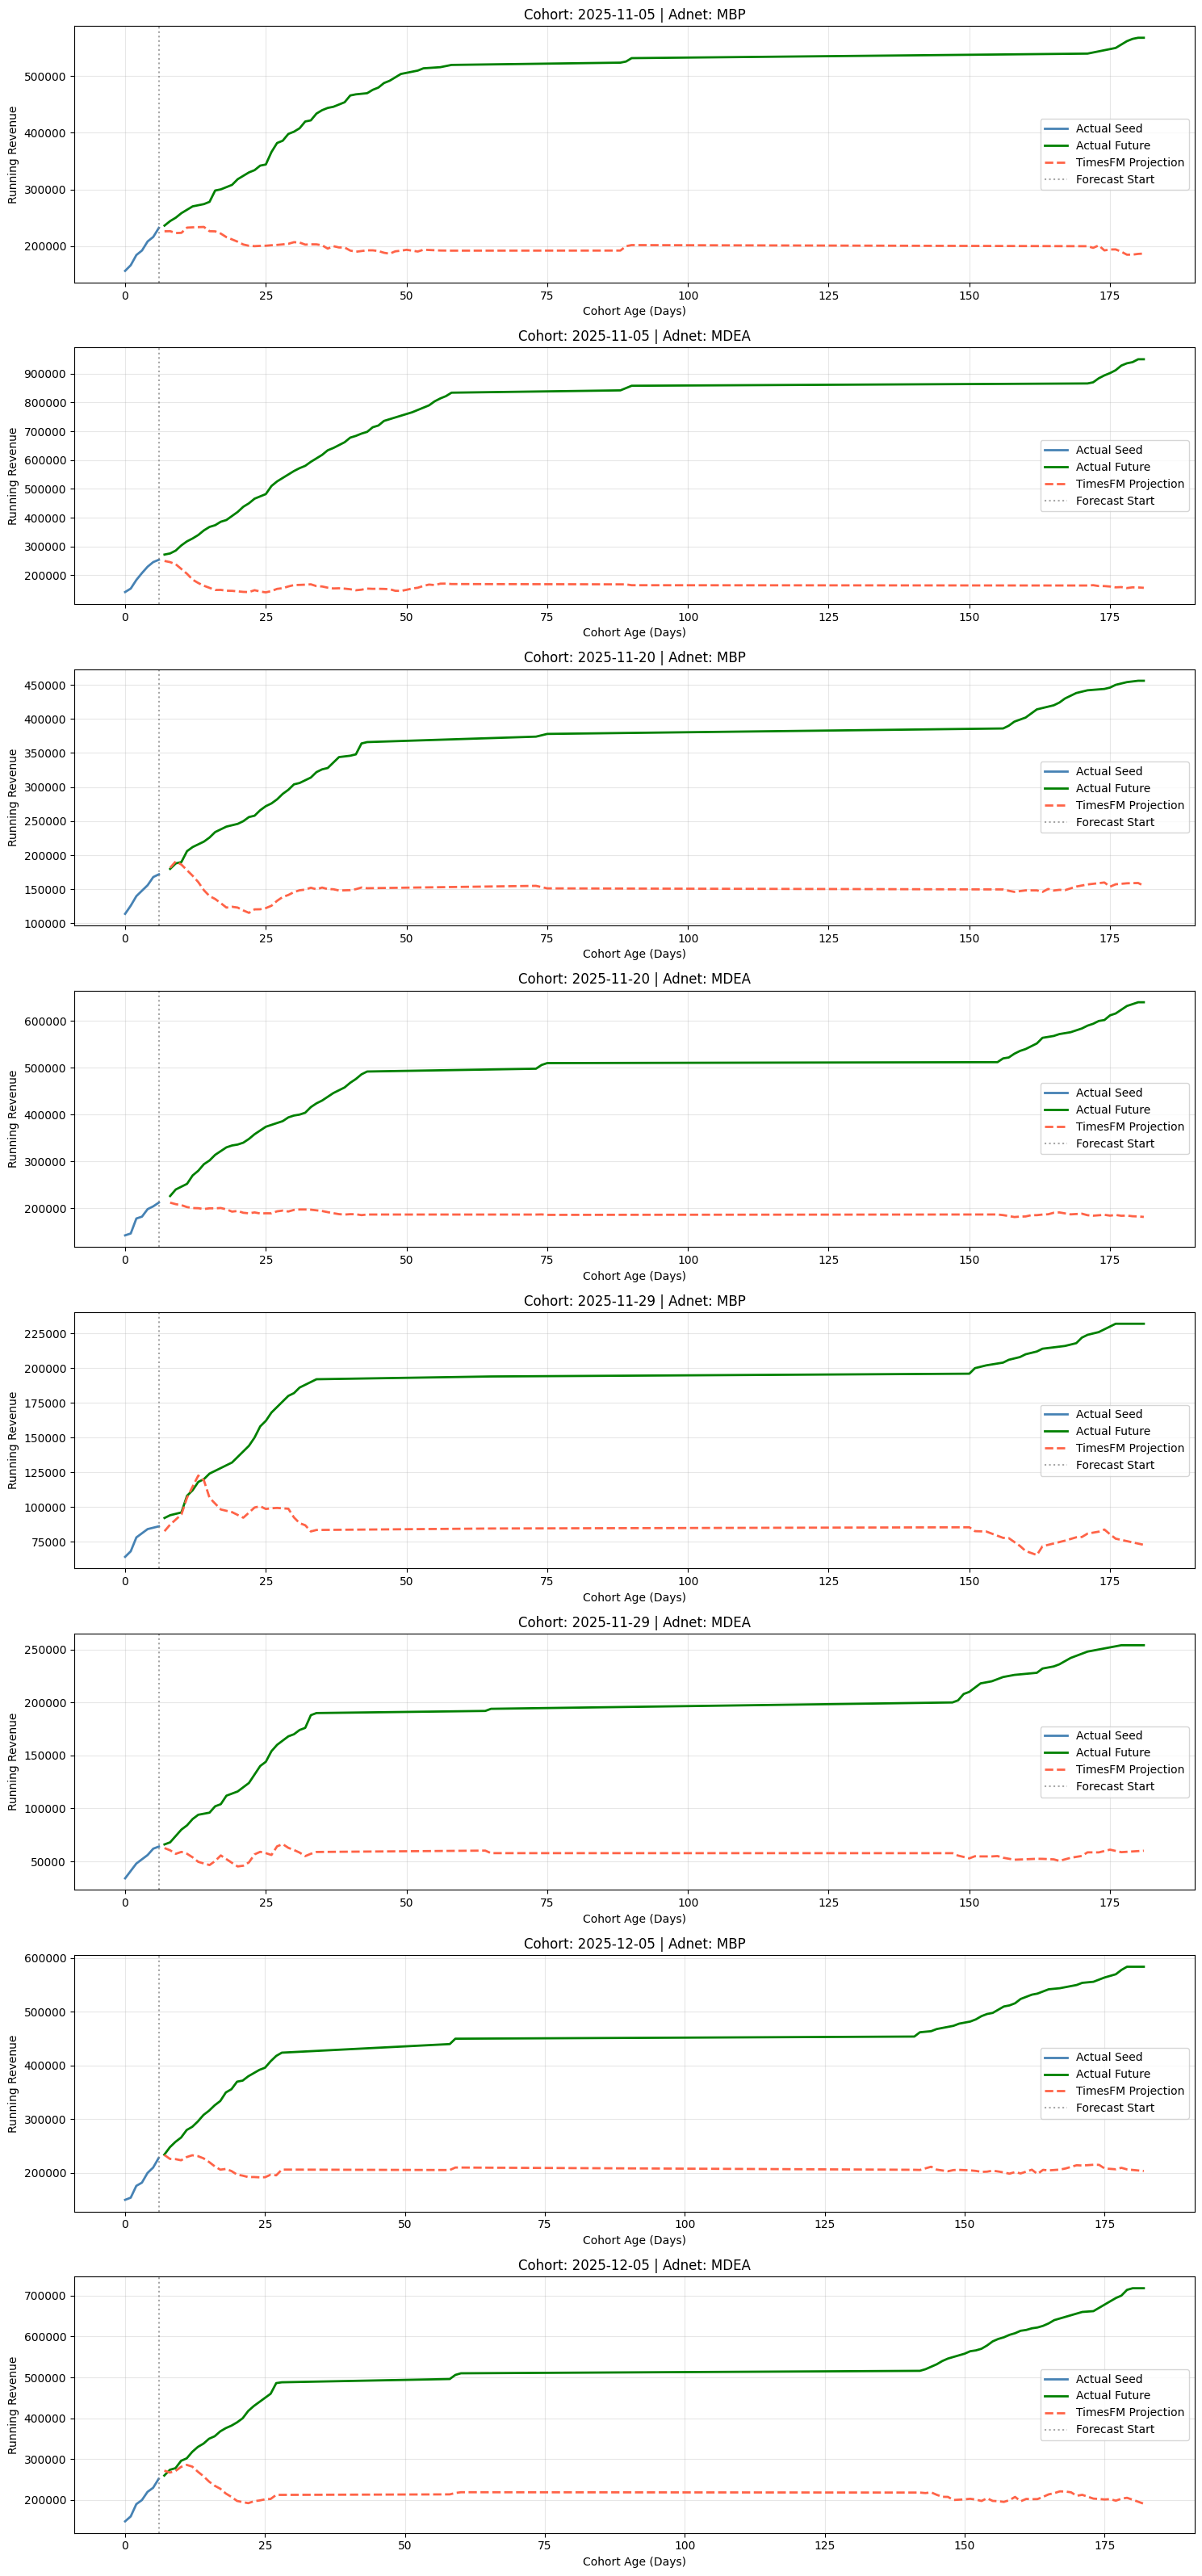

In [58]:
n_series = len(results)

fig, axes = plt.subplots(
    n_series,
    1,
    figsize=(15, 4 * n_series)
)

if n_series == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results.items()):

    cohort_raw = r["cohort_raw"]
    seed_len = r["seed_len"]
    n_steps = r["n_steps"]

    seed_mask = cohort_raw["cohort_age"] < seed_len

    ages = cohort_raw["cohort_age"].values

    seed_age = ages[seed_mask]
    future_age = ages[~seed_mask][:n_steps]
    pred_age = future_age[:len(r["pred_future"])]

    ax.plot(
        seed_age,
        r["context"],
        label="Actual Seed",
        color="steelblue",
        linewidth=2
    )

    ax.plot(
        future_age,
        r["actual_future"],
        label="Actual Future",
        color="green",
        linewidth=2
    )

    ax.plot(
        pred_age,
        r["pred_future"],
        label="TimesFM Projection",
        color="tomato",
        linestyle="--",
        linewidth=2
    )

    if len(seed_age) > 0:
        ax.axvline(
            x=seed_age[-1],
            color="gray",
            linestyle=":",
            alpha=0.7,
            label="Forecast Start"
        )

    ax.set_title(
        f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}"
    )

    ax.set_xlabel("Cohort Age (Days)")
    ax.set_ylabel("Running Revenue")

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()



## Forecast - 50 Cohorts - 5 Adnet - 30 Days

In [57]:
results = {}

for (cohort, adnet), cohort_raw in (
    df_unseen
    .groupby(["date_created_at", "adnet"])
):

    cohort_raw = (
        cohort_raw
        .sort_values("cohort_age")
        .reset_index(drop=True)
    )

    if len(cohort_raw) < 2:
        continue

    seed_len = min(SEED_DAYS, len(cohort_raw) - 1)

    context, actual_future, pred_future, n_steps = project_cohort(
        cohort_raw,
        seed_len
    )

    results[(cohort, adnet)] = {
        "cohort_raw": cohort_raw,
        "adnet": adnet,
        "seed_len": seed_len,
        "context": context,
        "actual_future": actual_future,
        "pred_future": pred_future,
        "n_steps": n_steps,
    }

    mape_full = (
        mean_absolute_percentage_error(
            actual_future,
            pred_future
        ) * 100
    )

    print(
        f"{str(cohort)[:10]} | {adnet:<6} "
        f"seed={seed_len:>2}d "
        f"forecast={n_steps:>3}d "
        f"| final pred={pred_future[-1]:>12,.0f} "
        f"actual={actual_future[-1]:>12,.0f} "
        f"MAPE={mape_full:.2f}%"
    )

2025-11-05 | MBP    seed=30d forecast= 38d | final pred=     623,877 actual=     568,000 MAPE=9.84%
2025-11-05 | MDEA   seed=30d forecast= 43d | final pred=   1,025,050 actual=     950,000 MAPE=12.14%
2025-11-20 | MBP    seed=30d forecast= 33d | final pred=     435,246 actual=     456,000 MAPE=5.17%
2025-11-20 | MDEA   seed=30d forecast= 42d | final pred=     537,777 actual=     640,000 MAPE=8.41%
2025-11-29 | MBP    seed=30d forecast= 24d | final pred=     251,563 actual=     232,000 MAPE=3.02%
2025-11-29 | MDEA   seed=30d forecast= 28d | final pred=     302,615 actual=     254,000 MAPE=13.22%
2025-12-05 | MBP    seed=30d forecast= 34d | final pred=     642,732 actual=     584,000 MAPE=3.70%
2025-12-05 | MDEA   seed=30d forecast= 41d | final pred=     957,864 actual=     718,000 MAPE=22.36%


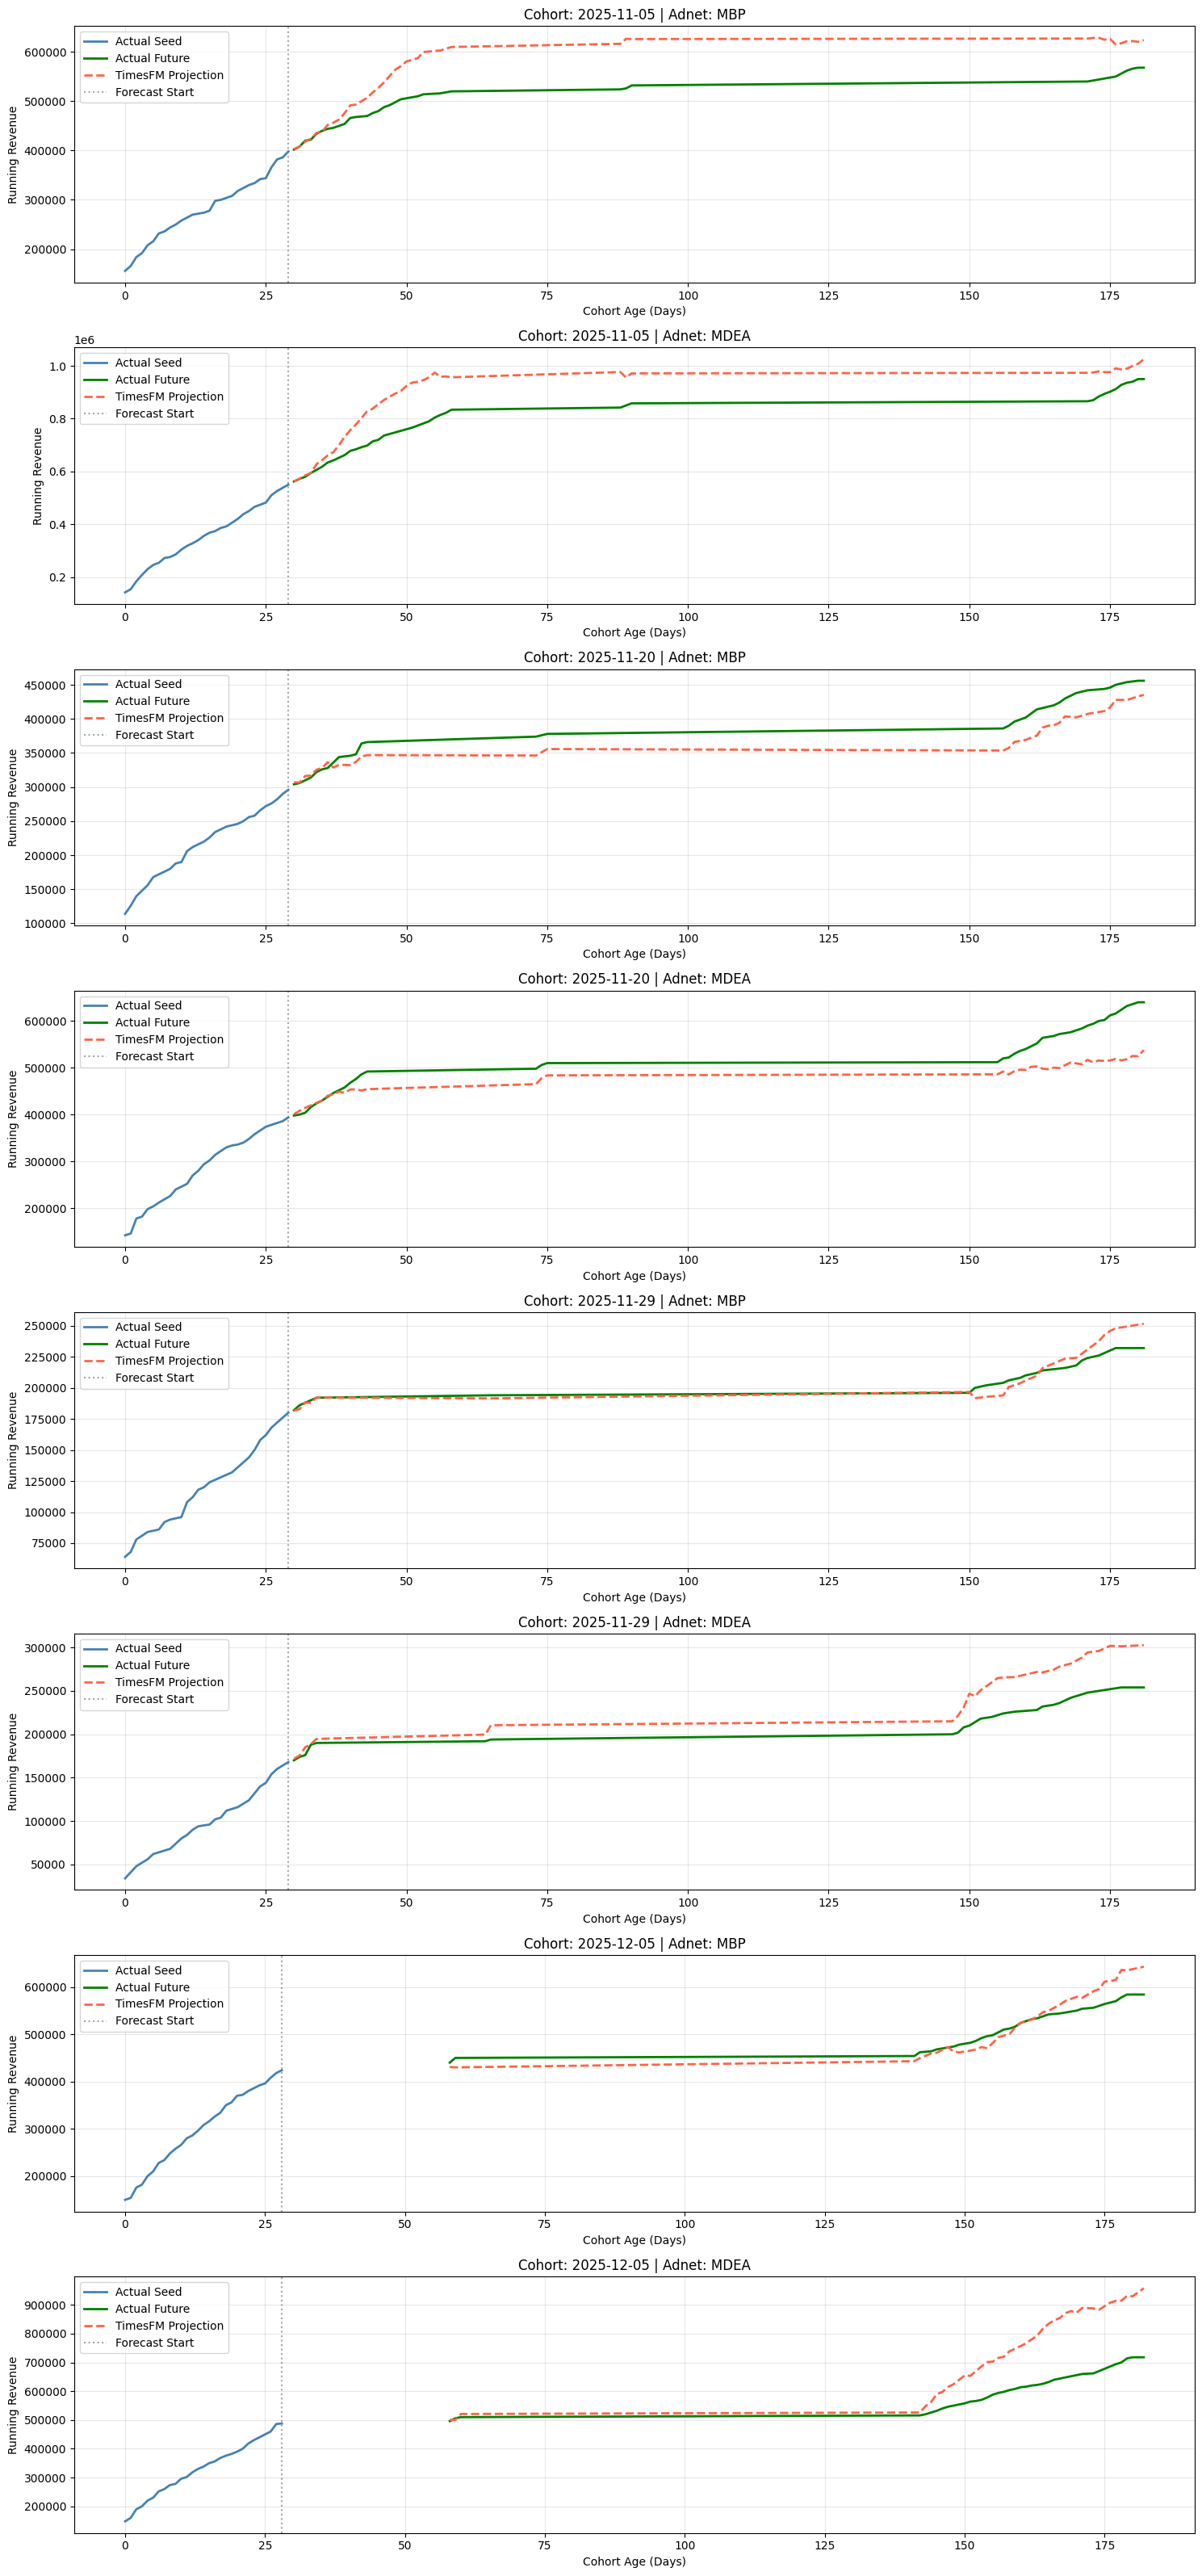

In [59]:
n_series = len(results)

fig, axes = plt.subplots(
    n_series,
    1,
    figsize=(15, 4 * n_series)
)

if n_series == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results.items()):

    cohort_raw = r["cohort_raw"]
    seed_len = r["seed_len"]
    n_steps = r["n_steps"]

    seed_mask = cohort_raw["cohort_age"] < seed_len

    ages = cohort_raw["cohort_age"].values

    seed_age = ages[seed_mask]
    future_age = ages[~seed_mask][:n_steps]
    pred_age = future_age[:len(r["pred_future"])]

    ax.plot(
        seed_age,
        r["context"],
        label="Actual Seed",
        color="steelblue",
        linewidth=2
    )

    ax.plot(
        future_age,
        r["actual_future"],
        label="Actual Future",
        color="green",
        linewidth=2
    )

    ax.plot(
        pred_age,
        r["pred_future"],
        label="TimesFM Projection",
        color="tomato",
        linestyle="--",
        linewidth=2
    )

    if len(seed_age) > 0:
        ax.axvline(
            x=seed_age[-1],
            color="gray",
            linestyle=":",
            alpha=0.7,
            label="Forecast Start"
        )

    ax.set_title(
        f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}"
    )

    ax.set_xlabel("Cohort Age (Days)")
    ax.set_ylabel("Running Revenue")

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()



## Forecast - 50 Cohorts - 5 Adnet - 60 Days

In [57]:
results = {}

for (cohort, adnet), cohort_raw in (
    df_unseen
    .groupby(["date_created_at", "adnet"])
):

    cohort_raw = (
        cohort_raw
        .sort_values("cohort_age")
        .reset_index(drop=True)
    )

    if len(cohort_raw) < 2:
        continue

    seed_len = min(SEED_DAYS, len(cohort_raw) - 1)

    context, actual_future, pred_future, n_steps = project_cohort(
        cohort_raw,
        seed_len
    )

    results[(cohort, adnet)] = {
        "cohort_raw": cohort_raw,
        "adnet": adnet,
        "seed_len": seed_len,
        "context": context,
        "actual_future": actual_future,
        "pred_future": pred_future,
        "n_steps": n_steps,
    }

    mape_full = (
        mean_absolute_percentage_error(
            actual_future,
            pred_future
        ) * 100
    )

    print(
        f"{str(cohort)[:10]} | {adnet:<6} "
        f"seed={seed_len:>2}d "
        f"forecast={n_steps:>3}d "
        f"| final pred={pred_future[-1]:>12,.0f} "
        f"actual={actual_future[-1]:>12,.0f} "
        f"MAPE={mape_full:.2f}%"
    )

2025-11-05 | MBP    seed=60d forecast= 14d | final pred=     551,938 actual=     568,000 MAPE=1.64%
2025-11-05 | MDEA   seed=60d forecast= 14d | final pred=     955,998 actual=     950,000 MAPE=1.14%
2025-11-20 | MBP    seed=60d forecast= 20d | final pred=     428,449 actual=     456,000 MAPE=5.11%
2025-11-20 | MDEA   seed=60d forecast= 28d | final pred=     608,041 actual=     640,000 MAPE=1.68%
2025-11-29 | MBP    seed=47d forecast= 19d | final pred=     225,130 actual=     232,000 MAPE=1.97%
2025-11-29 | MDEA   seed=55d forecast= 23d | final pred=     251,089 actual=     254,000 MAPE=1.62%
2025-12-05 | MBP    seed=60d forecast= 32d | final pred=     747,673 actual=     584,000 MAPE=14.58%
2025-12-05 | MDEA   seed=60d forecast= 39d | final pred=     909,243 actual=     718,000 MAPE=23.01%


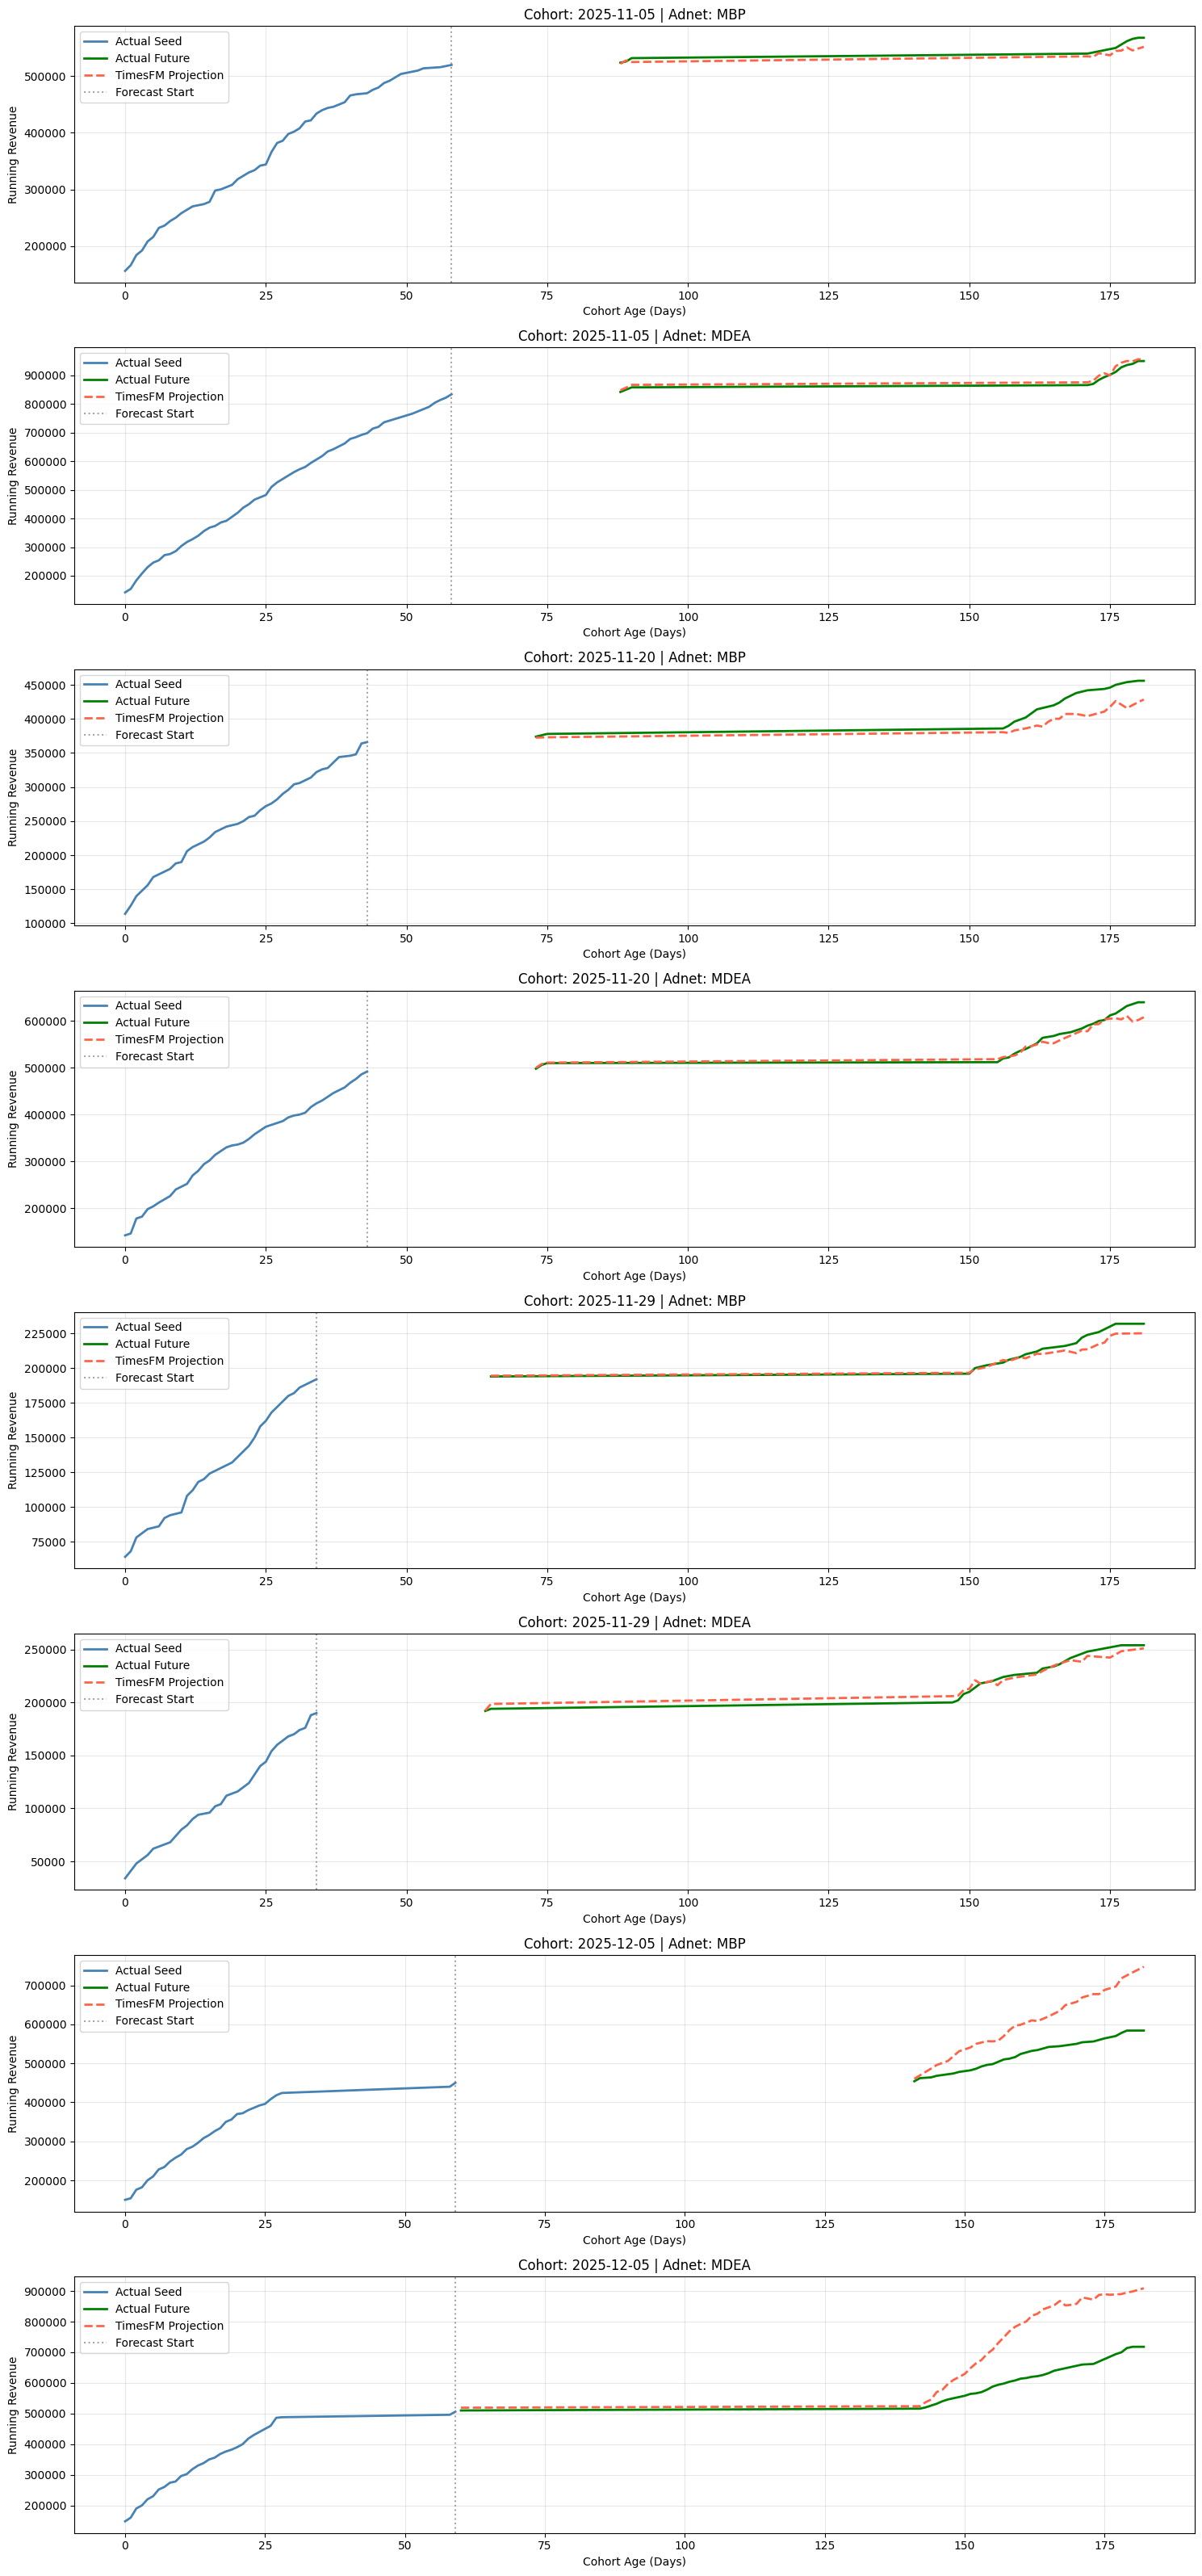

In [58]:
n_series = len(results)

fig, axes = plt.subplots(
    n_series,
    1,
    figsize=(15, 4 * n_series)
)

if n_series == 1:
    axes = [axes]

for ax, ((cohort, adnet), r) in zip(axes, results.items()):

    cohort_raw = r["cohort_raw"]
    seed_len = r["seed_len"]
    n_steps = r["n_steps"]

    seed_mask = cohort_raw["cohort_age"] < seed_len

    ages = cohort_raw["cohort_age"].values

    seed_age = ages[seed_mask]
    future_age = ages[~seed_mask][:n_steps]
    pred_age = future_age[:len(r["pred_future"])]

    ax.plot(
        seed_age,
        r["context"],
        label="Actual Seed",
        color="steelblue",
        linewidth=2
    )

    ax.plot(
        future_age,
        r["actual_future"],
        label="Actual Future",
        color="green",
        linewidth=2
    )

    ax.plot(
        pred_age,
        r["pred_future"],
        label="TimesFM Projection",
        color="tomato",
        linestyle="--",
        linewidth=2
    )

    if len(seed_age) > 0:
        ax.axvline(
            x=seed_age[-1],
            color="gray",
            linestyle=":",
            alpha=0.7,
            label="Forecast Start"
        )

    ax.set_title(
        f"Cohort: {str(cohort)[:10]} | Adnet: {adnet}"
    )

    ax.set_xlabel("Cohort Age (Days)")
    ax.set_ylabel("Running Revenue")

    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

